In [1]:
import sys
import os
# 获取当前 notebook 所在目录的父目录的父目录（即项目根目录）
project_root = os.path.dirname(os.path.dirname(os.path.abspath('.')))
sys.path.append(project_root)

In [3]:
from util import Score_calculate as score
from transformers import T5Tokenizer, T5ForConditionalGeneration
import pandas as pd
from tqdm import tqdm
import torch

In [4]:
# === 2. 定义生成函数 ===
def generate_smiles_from_caption(caption, tokenizer, model, max_length=128):
    inputs = tokenizer(caption, return_tensors="pt", truncation=True).to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=max_length,
            num_beams=5,
            early_stopping=True
        )
    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return decoded.strip()

In [5]:
# 微调模型生成指标测试
tokenizer = T5Tokenizer.from_pretrained(R"/mnt/slowdisk/ZYH/LLMCP/CheckPoint/SingMolT5_small/checkpoint-204", model_max_length=128)
model = T5ForConditionalGeneration.from_pretrained(R'/mnt/slowdisk/ZYH/LLMCP/CheckPoint/SingMolT5_small/checkpoint-204')

# === 载入测试集 ===
df = pd.read_csv("/home/zhaoyiheng/LLM/FT_MolT5/dataset/V6/MolGen_Test.csv")  # 包含 Caption 和 SMILES 列
captions = df["Caption"].tolist()
true_smiles = df["SMILES"].tolist()

# === 设备设置 ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# === 生成 SMILES ===
ft_generated_smiles = []
for caption in tqdm(captions, desc="Generating SMILES"):
    pred = generate_smiles_from_caption(caption, tokenizer, model)
    ft_generated_smiles.append(pred)

# === 计算评价指标 ===
with score.suppress_rdkit_warnings():
    results = score.evaluate_batch(true_smiles, ft_generated_smiles)

score.result_output(results)

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
Generating SMILES: 100%|██████████| 60/60 [00:11<00:00,  5.11it/s]


=== Evaluation Results (Average over Batch) ===
BLEU                  : 0.3132
Levenshtein Similarity: 0.4684
MACCS FTS             : 0.3682
RDK FTS               : 0.2091
Morgan FTS            : 0.2350
Validity              : 0.9667


In [6]:
# molt5指标测试
tokenizer = T5Tokenizer.from_pretrained(R"/mnt/slowdisk/ZYH/LLMCP/molt5small_cp2sm", model_max_length=128)
model = T5ForConditionalGeneration.from_pretrained(R'/mnt/slowdisk/ZYH/LLMCP/molt5small_cp2sm')

# === 载入测试集 ===
df = pd.read_csv("/home/zhaoyiheng/LLM/FT_MolT5/dataset/V6/MolGen_Test.csv") #包含Caption和SMILES列
captions = df["Caption"].tolist()
true_smiles = df["SMILES"].tolist()

# === 设备设置 ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# === 生成 SMILES ===
mt5_generated_smiles = []
for caption in tqdm(captions, desc="Generating SMILES"):
    pred = generate_smiles_from_caption(caption, tokenizer, model)
    mt5_generated_smiles.append(pred)

# === 计算评价指标 ===
with score.suppress_rdkit_warnings():
    results = score.evaluate_batch(true_smiles, mt5_generated_smiles)

score.result_output(results)

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
/usr/local/anaconda3/envs/zyhEnv/lib/python3.8/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
Generat


=== Evaluation Results (Average over Batch) ===
BLEU                  : 0.3285
Levenshtein Similarity: 0.4600
MACCS FTS             : 0.2827
RDK FTS               : 0.1336
Morgan FTS            : 0.1288
Validity              : 0.8333


In [7]:
# T5模型指标测试
tokenizer = T5Tokenizer.from_pretrained(R"/mnt/slowdisk/ZYH/LLMCP/t5samll_cp2sm", model_max_length=128)
model = T5ForConditionalGeneration.from_pretrained(R'/mnt/slowdisk/ZYH/LLMCP/t5samll_cp2sm')

# === 载入测试集 ===
df = pd.read_csv("/home/zhaoyiheng/LLM/FT_MolT5/dataset/V6/MolGen_Test.csv")
captions = df["Caption"].tolist()
true_smiles = df["SMILES"].tolist()

# === 设备设置 ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# === 生成 SMILES ===
t5_generated_smiles = []
for caption in tqdm(captions, desc="Generating SMILES"):
    pred = generate_smiles_from_caption(caption, tokenizer, model)
    t5_generated_smiles.append(pred)

# === 计算评价指标 ===
with score.suppress_rdkit_warnings():
    results = score.evaluate_batch(true_smiles, t5_generated_smiles)

score.result_output(results)

Generating SMILES: 100%|██████████| 60/60 [00:26<00:00,  2.26it/s]


=== Evaluation Results (Average over Batch) ===
BLEU                  : 0.3555
Levenshtein Similarity: 0.4649
MACCS FTS             : 0.1830
RDK FTS               : 0.0908
Morgan FTS            : 0.0865
Validity              : 0.5667


In [11]:
print(ft_generated_smiles)

['C1=CC=C(C=C1)C#N', 'C1=CC=C(C=C1)C#N', 'C1=CC=C(C=C1)C#N', 'C1=CC=C(C=C1)C2=CC=CC=C2', 'C1=CC=C(C=C1)C#CC2=CC=CC=C2', 'CCC1=CC=C(C=C1)C#CC2=CC=CC=C2', 'CSC1=CC=C(C=C1)S', 'CSC1=CC=C(C=C1)S', 'CSC1=CC=C(C=C1)S', 'C1=CC=C(C=C1)Br', 'C1=CC=C(C=C1)Br', 'C1=CC=C(C=C1)Br', 'CSC1=CC=C(C=C1)SC', 'CSC1=CC=C(C=C1)SC', 'CSC1=CC=C(C=C1)SC', 'CSC1=CC=C(C=C1)S', 'C1=CC=CC=C1S', 'C1=CC=C(C=C1)S', 'C1=CC=C(C=C1)S', 'CSC1=CC=C(C=C1)S', 'C1=CC=C(C=C1)S', 'CSC1=CC=C(C=C1)N', 'C1=CC=C(C=C1)C#N', 'CSC1=CC=C(C=C1)N', 'C1=CC=C(C=C1)C#N', 'C1=CC=C(C=C1)C#N', 'C1=CC=C(C=C1)C#N', 'C1=CC=C(C=C1)I', 'C1=CC=C(C=C1)I', 'C1=CC=C(C=C1)I', 'C1=CC=C(C=C1)SC', 'C1=CC=C(C=C1)SC', 'C1=CC=C(C=C1)S', 'C1=CC=C(C=C1)C#N', 'C1=CC=C(C=C1)SC', 'C1=CC=C1', 'C1=CC=C(C=C1)C#N', 'C1=CC=C(C=C1)C#N', 'C1=CC=C(C=C1)N', 'C1=CC=C(C=C1)C2=CC=C(C=C2)C=C1', 'C1=CC=C(C=C1)C#N', 'C1=CC=C(C=C1)C#CC2=CC=C(C=C2)C#N', 'CSC1=CC=C(C=C1)S', 'CSC1=CC=C(C=C1)SC', 'CSC1=CC=C(C=C1)S', 'CC1=CC=C(C=C1)C#CC2=CC=CC=C2', 'CSC1=CC=C(C=C1)C#N', 'CNC1=CC=C(C=

In [9]:
print(mt5_generated_smiles)

['C1=C(C(=O)NC(=O)N1)C(=O)O', 'CC(=O)C1=CNC(=O)C1', 'C1=CC=NC(=C1N)C(=O)O', 'C1=CC=C(C(=C1)C2=CC=CC=C2C(=O)O)C(=O)O', 'C1=CC=C(C=C1)C(C2=CC=CC=C2)C3=CC=CC=C3', 'CC1=C(C=C(C=C1)C2=CC=CC=C2C(=O)N)C3=CC=C(C=C3)C4=CC=CC=C4', 'C1=CC=C2C(=C1)C(=CN2)C3=C(C=C(C=C3)S(=O)(=O)N', 'C/C(=CC(=O)OCC(C)C)/C=C/C(=O)C(=O)C(=O)O', 'C/C(=CC(=O)N)/C=C/C(=O)SCCNC(=O)CCNC(=O)[C@@H](C(C)C)S(=O)(=O)C', 'C1=CC=C(C=C1)C2=CC=CC=C2N(C1=O)CCC3=CC=CC=C3', 'C1=CC=C(C=C1)C2=CC=C(C=C2)N=NC3=CC=C(C=C3)N', 'C1=CC=C(C=C1)C2=CC=CC=C2N=CC=O', 'CC(C)(C)O', 'CSCCCCCCCCC(=O)O', 'CSCCCCCC[C@H](C)CCCC(C)C', 'C1=CC=C(C=C1)C2C(C(=O)NC(=O)N2)C(=O)O', 'C1=CC=NC(=C1)S(=O)(=O)[O-]', 'C1=CC(=CC=C1C(=O)N[C@@H](C2=CC=C(C=C2)S(=O)(=O)[O-])C3=CN=CC=C3', 'C1=CC=C(C=C1)/C=CC2=C(NC=N2)C3=NC=C(C=C3)C4=CN=CC=C4', 'C1=C(C=[N+](C=C1C(=O)N)SCC(=O)[O-]', 'C1=CN(C(=O)NC1=O)[C@H]2[C@@H]([C@@H]([C@H](O2)CO)O)O', 'CC1=C(C(=C(C=C1)C)N)C', 'C(C#N)C(C(=O)O)N', 'CC(C)(C)N', 'C1=CC=C(C=C1)C#N', 'C1=CC=C(C=C1)C2=C(C(=C(C=C2)C#N)C#C)C#C', 'C1=CC=C(C=C1)C2=C(C

In [10]:
print(t5_generated_smiles)

['CC(=O)C1=C(N=CC=C1)C(=O)C2=CN=CC=C2', 'CC(C1=CN=C(C=C1)C(=O)C2=CC=CC=C2', 'CC(=O)CCC1=CNC2=C1C=C(C=C2)C(=O)C[C@@H](C=C2)CCC(=O)O', 'C1=CC=C(C=C1)CCC2=CC=C(C=C2)C3=CC=CC=C3', 'C1=CC=C(C=C1)CC2=CC=C(C=C2)C3=CC=CC=C3', 'CCCC(=O)C(C)C1=CC=C(C=C1)C2=CC=CC=C2', 'C12=C(C(=C(C(=C1C=C2C(=N1)C(=O)N2)C)C(=O)N[C@@H](CC3=CC=CC=C3)C4=CC=CC=C4)C=C4', 'C1=CC=C2C(=C1)C2=C(C(=C(C=C2)C)Cl)Cl', 'C1=CC=C2C(=C1)C(=O)C3=CC=CC=C3C2=O', 'C1=CC(=CC=C1C[C@@H](C(=O)O)N)N', 'C1=CC=C(C(=C1)C2=CC=CC=C2', 'C1=CC(=C(C=C1C2=CC=C(C=C2)C3=CC=C(C=C3)N', 'C[C@H](C1=CC=C(C=C1)C(=O)N2C=NC=C2C(=O)[C@H](C(=O)N)C', 'C[C@@H](C1=CC=CC=C1)C2=CC(=O)C3=CC=CC=C3', 'C[C@H]([C@H](C)C(C)C(=O)O)O)C', 'C1=CC(=CN=C1)C(=O)O', 'CC(=O)NC1=C(N=CC=C1N)C2=CC=CC=N2', 'C1=CC=NC(=C1)C(=O)C2=C(N(C=C2)S(=O)(=O)[O-])C(=O)O', 'C1=C(N(C(=O)NC1=O)C(=O)N2C=CC(=N2)C3=CN=CC=C3', 'C1=C(C(=NC(=O)C1=O)C(=O)O)C2=CC=CC=N2', 'CC1=CN=C(N=C1)C(=O)C[C@@H](C(=O)O)N', 'C[C@H](CCC1=CC=CC=C1)C2=CC=CC=C2', 'C1=CC=C2C(=C1)C=CC(=C2N=NC3=C(C=C(C4=CC=CC=C4)C(=O)N(C)C)C(=O)

Aromatic: C1=CC=C(C=C1)C#N
Kekule:   N#CC1=CC=CC=C1

Structure of N#CC1=CC=CC=C1


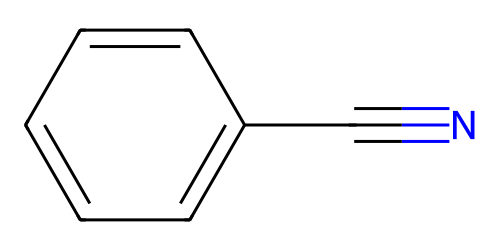

Aromatic: C1=CC=C(C=C1)C#N
Kekule:   N#CC1=CC=CC=C1

Structure of N#CC1=CC=CC=C1


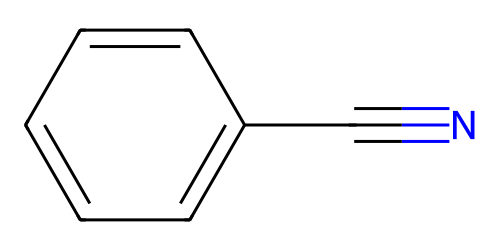

Aromatic: C1=CC=C(C=C1)C#N
Kekule:   N#CC1=CC=CC=C1

Structure of N#CC1=CC=CC=C1


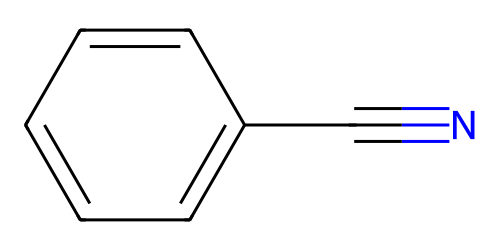

Aromatic: C1=CC=C(C=C1)C2=CC=CC=C2
Kekule:   C1=CC=C(C2=CC=CC=C2)C=C1

Structure of C1=CC=C(C2=CC=CC=C2)C=C1


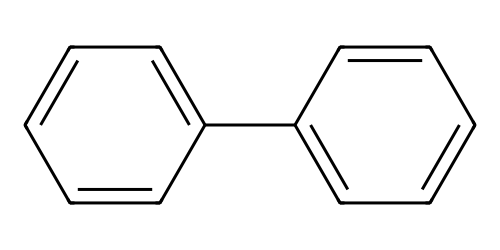

Aromatic: C1=CC=C(C=C1)C#CC2=CC=CC=C2
Kekule:   C(#CC1=CC=CC=C1)C1=CC=CC=C1

Structure of C(#CC1=CC=CC=C1)C1=CC=CC=C1


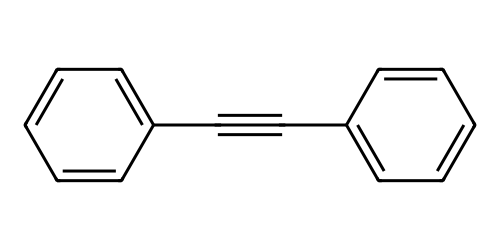

Aromatic: CCC1=CC=C(C=C1)C#CC2=CC=CC=C2
Kekule:   CCC1=CC=C(C#CC2=CC=CC=C2)C=C1

Structure of CCC1=CC=C(C#CC2=CC=CC=C2)C=C1


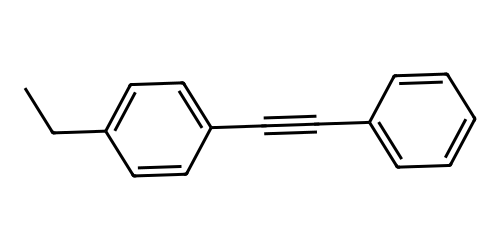

Aromatic: CSC1=CC=C(C=C1)S
Kekule:   CSC1=CC=C(S)C=C1

Structure of CSC1=CC=C(S)C=C1


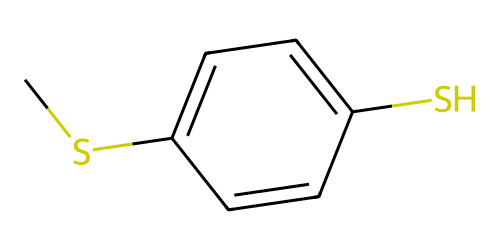

Aromatic: CSC1=CC=C(C=C1)S
Kekule:   CSC1=CC=C(S)C=C1

Structure of CSC1=CC=C(S)C=C1


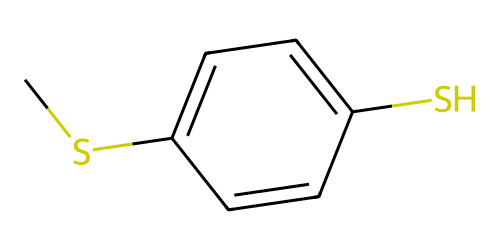

Aromatic: CSC1=CC=C(C=C1)S
Kekule:   CSC1=CC=C(S)C=C1

Structure of CSC1=CC=C(S)C=C1


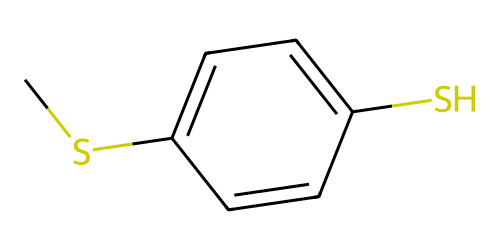

Aromatic: C1=CC=C(C=C1)Br
Kekule:   BrC1=CC=CC=C1

Structure of BrC1=CC=CC=C1


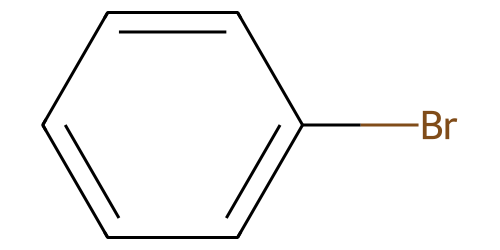

Aromatic: C1=CC=C(C=C1)Br
Kekule:   BrC1=CC=CC=C1

Structure of BrC1=CC=CC=C1


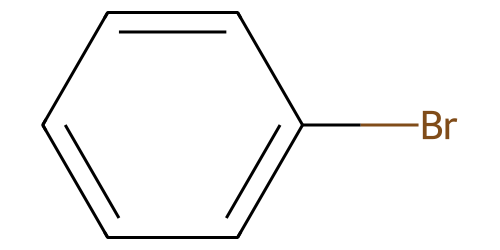

Aromatic: C1=CC=C(C=C1)Br
Kekule:   BrC1=CC=CC=C1

Structure of BrC1=CC=CC=C1


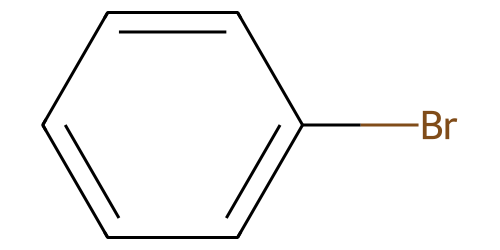

Aromatic: CSC1=CC=C(C=C1)SC
Kekule:   CSC1=CC=C(SC)C=C1

Structure of CSC1=CC=C(SC)C=C1


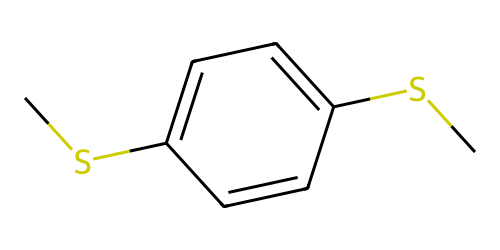

Aromatic: CSC1=CC=C(C=C1)SC
Kekule:   CSC1=CC=C(SC)C=C1

Structure of CSC1=CC=C(SC)C=C1


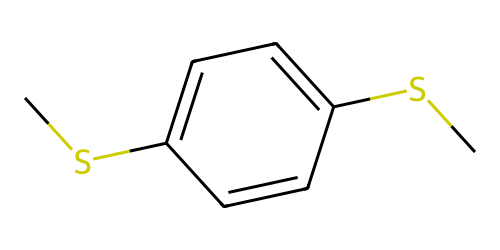

Aromatic: CSC1=CC=C(C=C1)SC
Kekule:   CSC1=CC=C(SC)C=C1

Structure of CSC1=CC=C(SC)C=C1


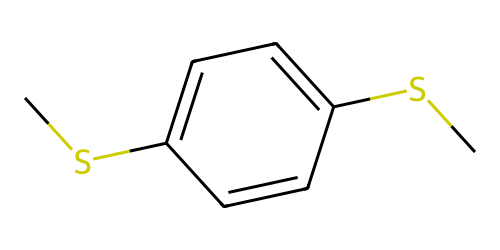

Aromatic: CSC1=CC=C(C=C1)S
Kekule:   CSC1=CC=C(S)C=C1

Structure of CSC1=CC=C(S)C=C1


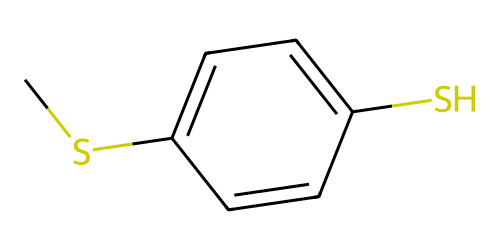

Aromatic: C1=CC=CC=C1S
Kekule:   SC1=CC=CC=C1

Structure of SC1=CC=CC=C1


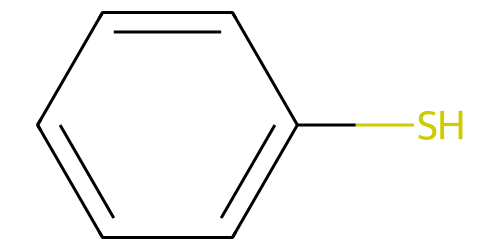

Aromatic: C1=CC=C(C=C1)S
Kekule:   SC1=CC=CC=C1

Structure of SC1=CC=CC=C1


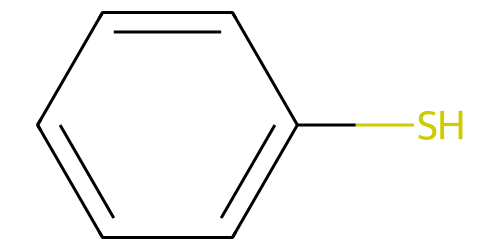

Aromatic: C1=CC=C(C=C1)S
Kekule:   SC1=CC=CC=C1

Structure of SC1=CC=CC=C1


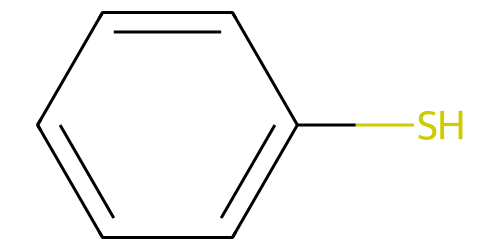

Aromatic: CSC1=CC=C(C=C1)S
Kekule:   CSC1=CC=C(S)C=C1

Structure of CSC1=CC=C(S)C=C1


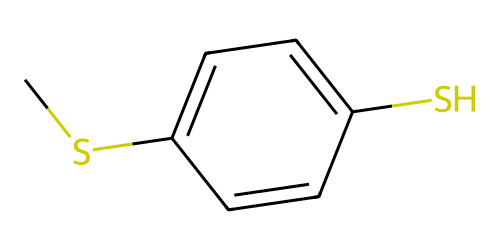

Aromatic: C1=CC=C(C=C1)S
Kekule:   SC1=CC=CC=C1

Structure of SC1=CC=CC=C1


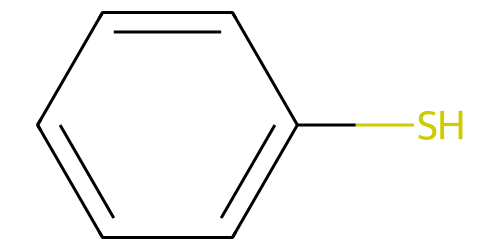

Aromatic: CSC1=CC=C(C=C1)N
Kekule:   CSC1=CC=C(N)C=C1

Structure of CSC1=CC=C(N)C=C1


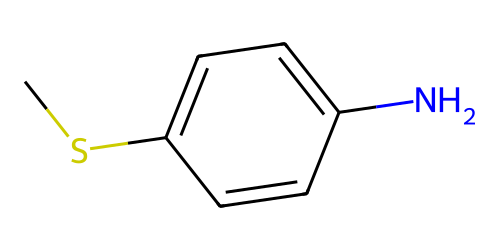

Aromatic: C1=CC=C(C=C1)C#N
Kekule:   N#CC1=CC=CC=C1

Structure of N#CC1=CC=CC=C1


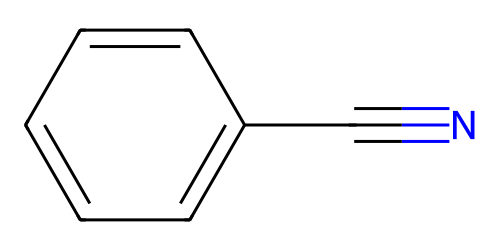

Aromatic: CSC1=CC=C(C=C1)N
Kekule:   CSC1=CC=C(N)C=C1

Structure of CSC1=CC=C(N)C=C1


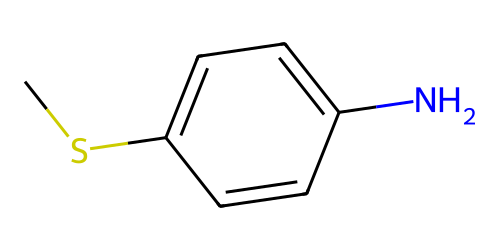

Aromatic: C1=CC=C(C=C1)C#N
Kekule:   N#CC1=CC=CC=C1

Structure of N#CC1=CC=CC=C1


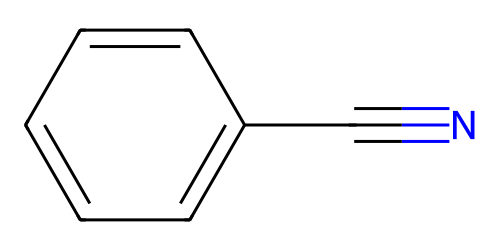

Aromatic: C1=CC=C(C=C1)C#N
Kekule:   N#CC1=CC=CC=C1

Structure of N#CC1=CC=CC=C1


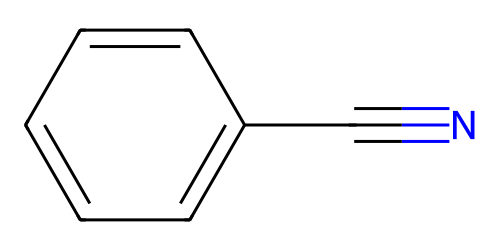

Aromatic: C1=CC=C(C=C1)C#N
Kekule:   N#CC1=CC=CC=C1

Structure of N#CC1=CC=CC=C1


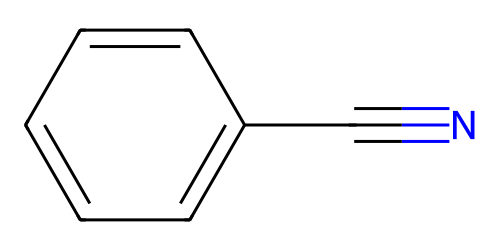

Aromatic: C1=CC=C(C=C1)I
Kekule:   IC1=CC=CC=C1

Structure of IC1=CC=CC=C1


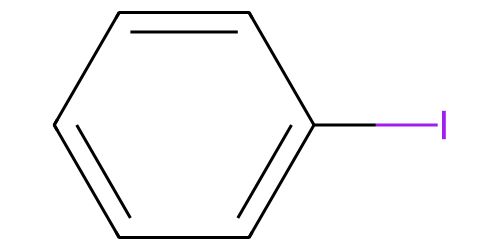

Aromatic: C1=CC=C(C=C1)I
Kekule:   IC1=CC=CC=C1

Structure of IC1=CC=CC=C1


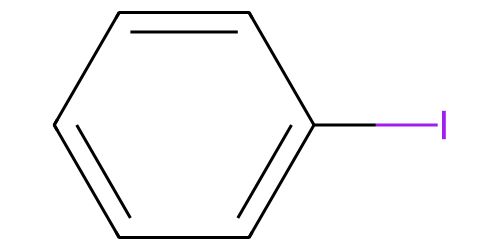

Aromatic: C1=CC=C(C=C1)I
Kekule:   IC1=CC=CC=C1

Structure of IC1=CC=CC=C1


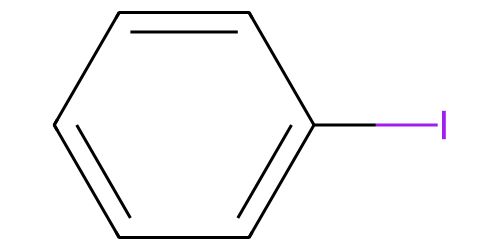

Aromatic: C1=CC=C(C=C1)SC
Kekule:   CSC1=CC=CC=C1

Structure of CSC1=CC=CC=C1


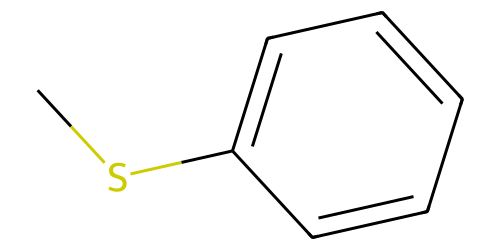

Aromatic: C1=CC=C(C=C1)SC
Kekule:   CSC1=CC=CC=C1

Structure of CSC1=CC=CC=C1


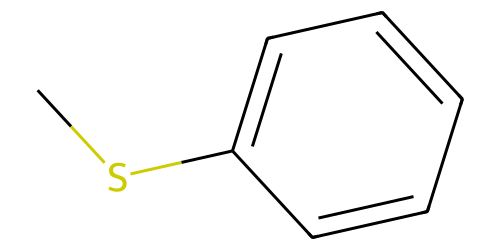

Aromatic: C1=CC=C(C=C1)S
Kekule:   SC1=CC=CC=C1

Structure of SC1=CC=CC=C1


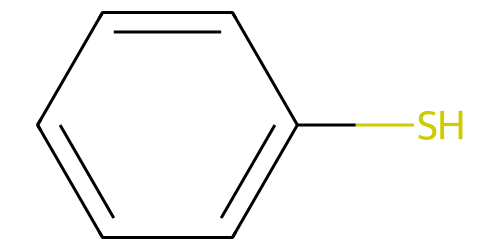

Aromatic: C1=CC=C(C=C1)C#N
Kekule:   N#CC1=CC=CC=C1

Structure of N#CC1=CC=CC=C1


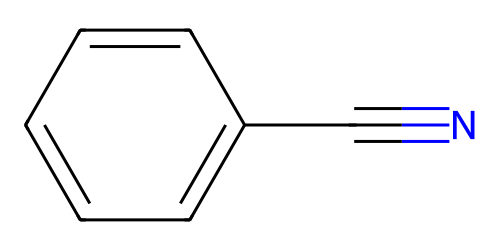

Aromatic: C1=CC=C(C=C1)SC
Kekule:   CSC1=CC=CC=C1

Structure of CSC1=CC=CC=C1


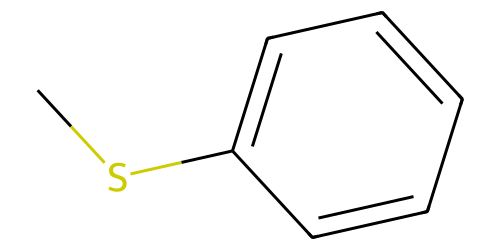

Aromatic: C1=CC=C1
Kekule:   C1=CC=C1

Structure of C1=CC=C1


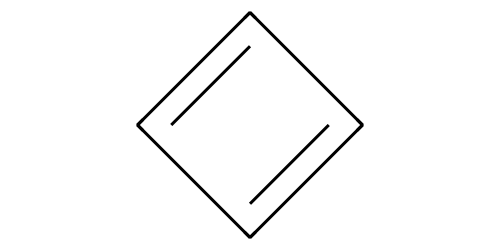

Aromatic: C1=CC=C(C=C1)C#N
Kekule:   N#CC1=CC=CC=C1

Structure of N#CC1=CC=CC=C1


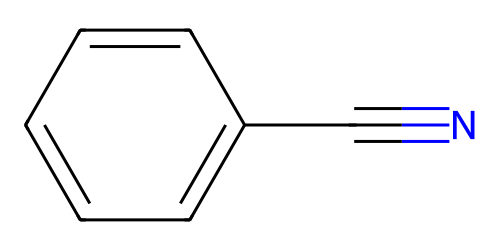

Aromatic: C1=CC=C(C=C1)C#N
Kekule:   N#CC1=CC=CC=C1

Structure of N#CC1=CC=CC=C1


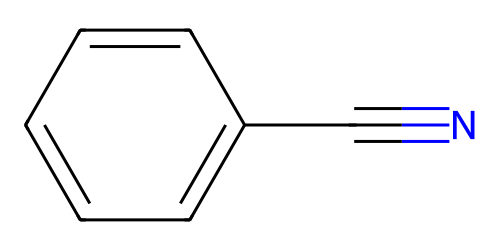

Aromatic: C1=CC=C(C=C1)N
Kekule:   NC1=CC=CC=C1

Structure of NC1=CC=CC=C1


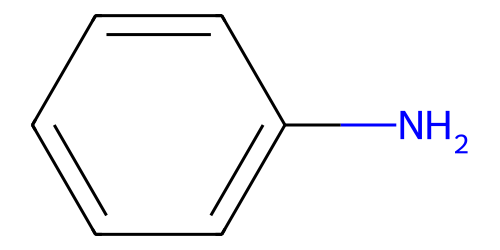

Aromatic: C1=CC=C(C=C1)C2=CC=C(C=C2)C=C1
Kekule:   None

Aromatic: C1=CC=C(C=C1)C#N
Kekule:   N#CC1=CC=CC=C1

Structure of N#CC1=CC=CC=C1


[16:08:30] SMILES Parse Error: unclosed ring for input: 'C1=CC=C(C=C1)C2=CC=C(C=C2)C=C1'


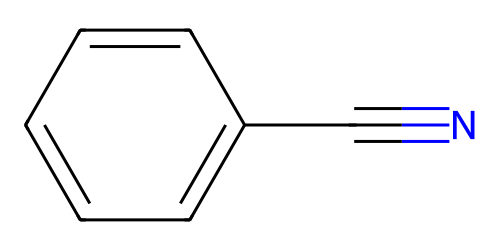

Aromatic: C1=CC=C(C=C1)C#CC2=CC=C(C=C2)C#N
Kekule:   N#CC1=CC=C(C#CC2=CC=CC=C2)C=C1

Structure of N#CC1=CC=C(C#CC2=CC=CC=C2)C=C1


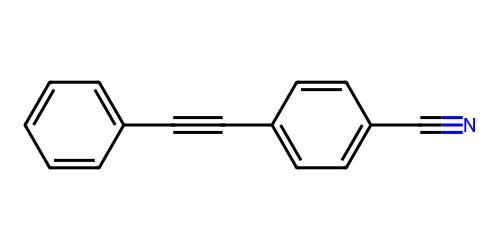

Aromatic: CSC1=CC=C(C=C1)S
Kekule:   CSC1=CC=C(S)C=C1

Structure of CSC1=CC=C(S)C=C1


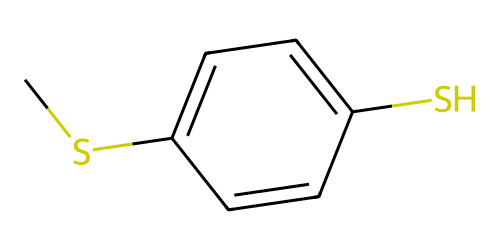

Aromatic: CSC1=CC=C(C=C1)SC
Kekule:   CSC1=CC=C(SC)C=C1

Structure of CSC1=CC=C(SC)C=C1


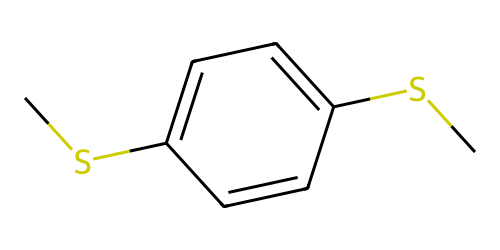

Aromatic: CSC1=CC=C(C=C1)S
Kekule:   CSC1=CC=C(S)C=C1

Structure of CSC1=CC=C(S)C=C1


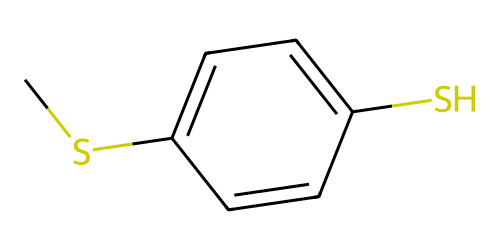

Aromatic: CC1=CC=C(C=C1)C#CC2=CC=CC=C2
Kekule:   CC1=CC=C(C#CC2=CC=CC=C2)C=C1

Structure of CC1=CC=C(C#CC2=CC=CC=C2)C=C1


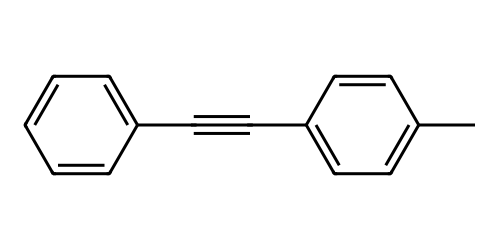

Aromatic: CSC1=CC=C(C=C1)C#N
Kekule:   CSC1=CC=C(C#N)C=C1

Structure of CSC1=CC=C(C#N)C=C1


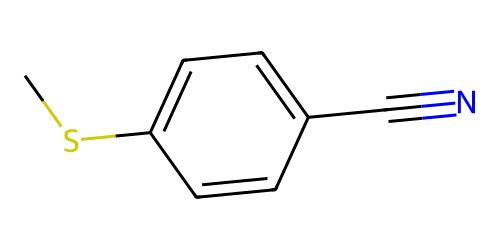

Aromatic: CNC1=CC=C(C=C1)C#N
Kekule:   CNC1=CC=C(C#N)C=C1

Structure of CNC1=CC=C(C#N)C=C1


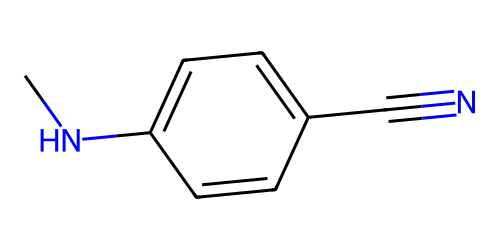

Aromatic: C1=CC=C(C=C1)C#N
Kekule:   N#CC1=CC=CC=C1

Structure of N#CC1=CC=CC=C1


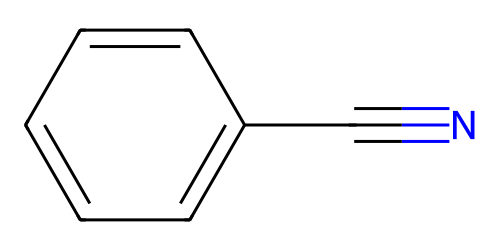

Aromatic: C1=CC=C(C=C1)C#N
Kekule:   N#CC1=CC=CC=C1

Structure of N#CC1=CC=CC=C1


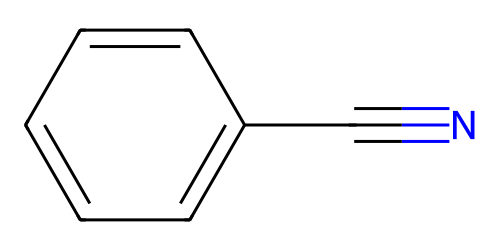

Aromatic: C1=CC=C(C=C1)C2=CC=C(C=C2)C=C1
Kekule:   None

Aromatic: C1=CC=C(C=C1)N
Kekule:   NC1=CC=CC=C1

Structure of NC1=CC=CC=C1


[16:08:30] SMILES Parse Error: unclosed ring for input: 'C1=CC=C(C=C1)C2=CC=C(C=C2)C=C1'


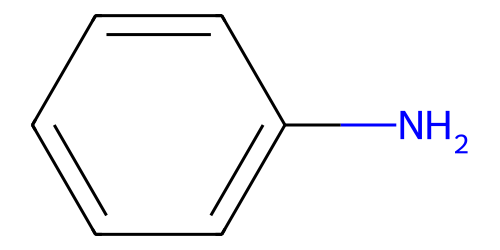

Aromatic: C1=CC=C(C=C1)N
Kekule:   NC1=CC=CC=C1

Structure of NC1=CC=CC=C1


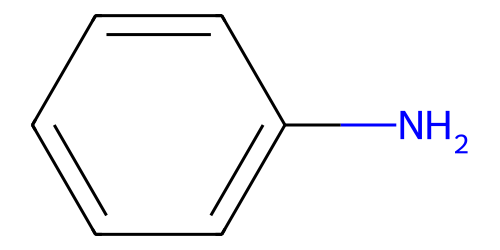

Aromatic: C1=CC=C(C=C1)N
Kekule:   NC1=CC=CC=C1

Structure of NC1=CC=CC=C1


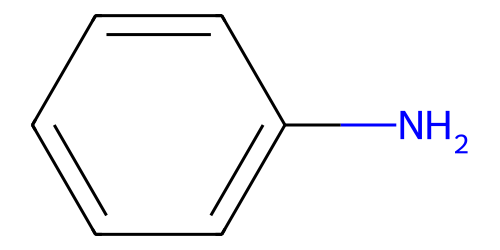

Aromatic: C1=CC=C(C=C1)N
Kekule:   NC1=CC=CC=C1

Structure of NC1=CC=CC=C1


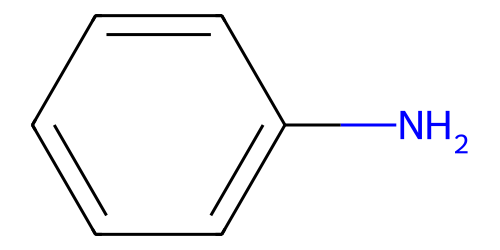

Aromatic: C1=CC=C(C=C1)C#N
Kekule:   N#CC1=CC=CC=C1

Structure of N#CC1=CC=CC=C1


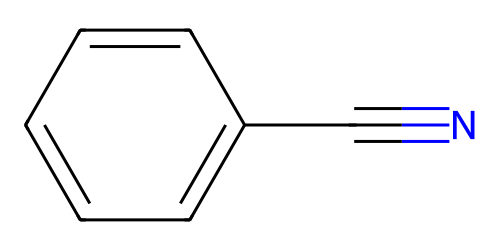

Aromatic: C1=CC=C(C=C1)N
Kekule:   NC1=CC=CC=C1

Structure of NC1=CC=CC=C1


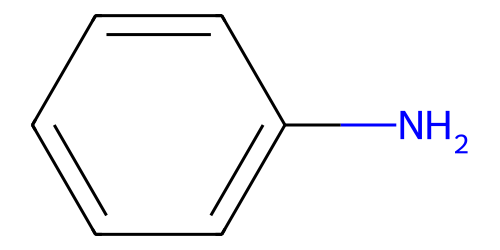

Aromatic: C1=CC=C(C=C1)C#N
Kekule:   N#CC1=CC=CC=C1

Structure of N#CC1=CC=CC=C1


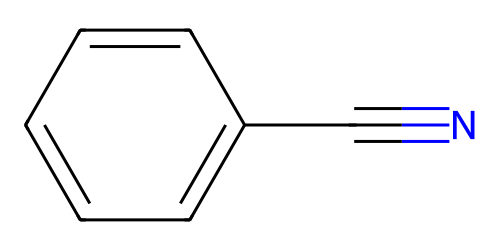

Aromatic: C1=CC=C(C=C1)C#N
Kekule:   N#CC1=CC=CC=C1

Structure of N#CC1=CC=CC=C1


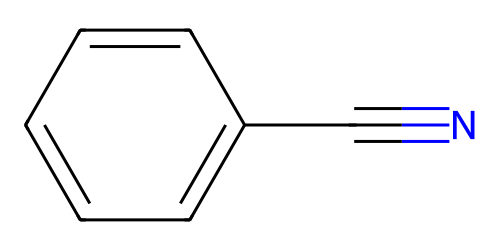

Aromatic: C1=CC=C(C=C1)C(=O)O
Kekule:   O=C(O)C1=CC=CC=C1

Structure of O=C(O)C1=CC=CC=C1


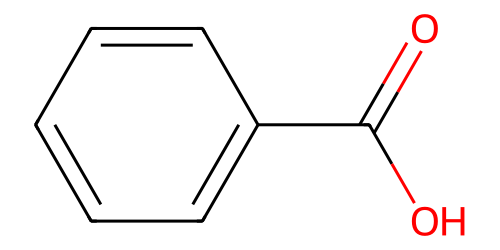

In [12]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display, Image
# 示例 SMILES（芳香式）
aromatic_smiles = ft_generated_smiles
def de_aromatize_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    try:
        # 执行反芳香化
        Chem.Kekulize(mol, clearAromaticFlags=True)
        # 转换为显式键的 SMILES（非芳香式）
        return Chem.MolToSmiles(mol, kekuleSmiles=True)
    except Exception as e:
        print(f"Failed to kekulize {smiles}: {e}")
        return None

# 批量转换并绘制高分辨率图像
for smi in aromatic_smiles:
    # 反芳香化
    kekule = de_aromatize_smiles(smi)
    print(f"Aromatic: {smi}\nKekule:   {kekule}\n")
    
    # 显示生成结构的高分辨率图像
    if kekule:
        print(f"Structure of {kekule}")
        mol2 = Chem.MolFromSmiles(kekule)
        
        # 使用 MolDraw2DCairo 生成高分辨率图像
        drawer = Draw.MolDraw2DCairo(500, 250)  # 设置画布尺寸
        options = drawer.drawOptions()
        options.minFontSize = 10
        options.bondLineWidth = 3
        options.padding = 0.05
        # 设置 DPI
        options.dpi = 300  # 设置 DPI 为 600（高分辨率）
        
        # 绘制分子
        drawer.DrawMolecule(mol2)
        drawer.FinishDrawing()

        # 获取绘制文本并显示图像
        img_data = drawer.GetDrawingText()
        img = Image(data=img_data)
        display(img)  # 直接显示图像在 Jupyter 输出框中


Aromatic: C1=C(C(=O)NC(=O)N1)C(=O)O
Kekule:   O=C1NC=C(C(=O)O)C(=O)N1

Structure of O=C1NC=C(C(=O)O)C(=O)N1


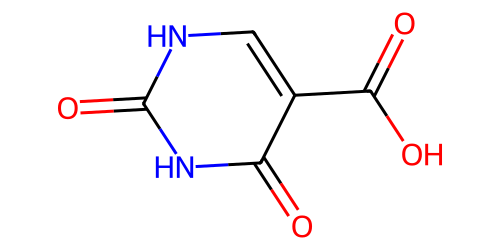

Aromatic: CC(=O)C1=CNC(=O)C1
Kekule:   CC(=O)C1=CNC(=O)C1

Structure of CC(=O)C1=CNC(=O)C1


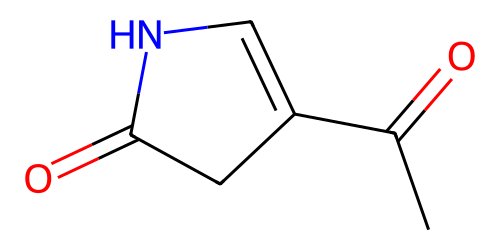

Aromatic: C1=CC=NC(=C1N)C(=O)O
Kekule:   NC1=C(C(=O)O)N=CC=C1

Structure of NC1=C(C(=O)O)N=CC=C1


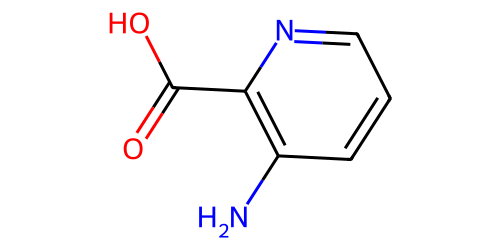

Aromatic: C1=CC=C(C(=C1)C2=CC=CC=C2C(=O)O)C(=O)O
Kekule:   O=C(O)C1=CC=CC=C1C1=CC=CC=C1C(=O)O

Structure of O=C(O)C1=CC=CC=C1C1=CC=CC=C1C(=O)O


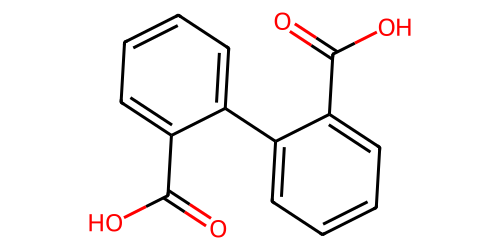

Aromatic: C1=CC=C(C=C1)C(C2=CC=CC=C2)C3=CC=CC=C3
Kekule:   C1=CC=C(C(C2=CC=CC=C2)C2=CC=CC=C2)C=C1

Structure of C1=CC=C(C(C2=CC=CC=C2)C2=CC=CC=C2)C=C1


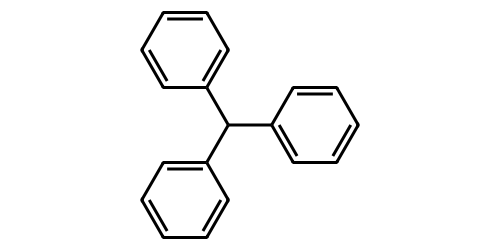

Aromatic: CC1=C(C=C(C=C1)C2=CC=CC=C2C(=O)N)C3=CC=C(C=C3)C4=CC=CC=C4
Kekule:   CC1=C(C2=CC=C(C3=CC=CC=C3)C=C2)C=C(C2=CC=CC=C2C(N)=O)C=C1

Structure of CC1=C(C2=CC=C(C3=CC=CC=C3)C=C2)C=C(C2=CC=CC=C2C(N)=O)C=C1


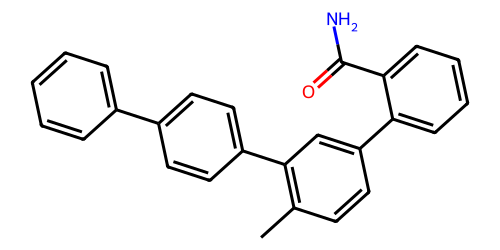

Aromatic: C1=CC=C2C(=C1)C(=CN2)C3=C(C=C(C=C3)S(=O)(=O)N
Kekule:   None

Aromatic: C/C(=CC(=O)OCC(C)C)/C=C/C(=O)C(=O)C(=O)O
Kekule:   CC(=CC(=O)OCC(C)C)/C=C/C(=O)C(=O)C(=O)O

Structure of CC(=CC(=O)OCC(C)C)/C=C/C(=O)C(=O)C(=O)O


[16:08:33] SMILES Parse Error: extra open parentheses for input: 'C1=CC=C2C(=C1)C(=CN2)C3=C(C=C(C=C3)S(=O)(=O)N'


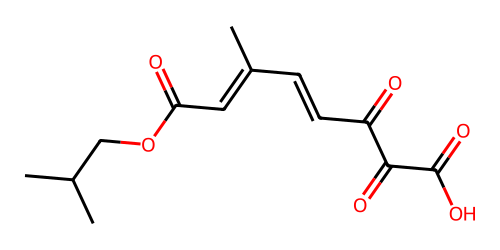

Aromatic: C/C(=CC(=O)N)/C=C/C(=O)SCCNC(=O)CCNC(=O)[C@@H](C(C)C)S(=O)(=O)C
Kekule:   CC(=CC(N)=O)/C=C/C(=O)SCCNC(=O)CCNC(=O)[C@@H](C(C)C)S(C)(=O)=O

Structure of CC(=CC(N)=O)/C=C/C(=O)SCCNC(=O)CCNC(=O)[C@@H](C(C)C)S(C)(=O)=O


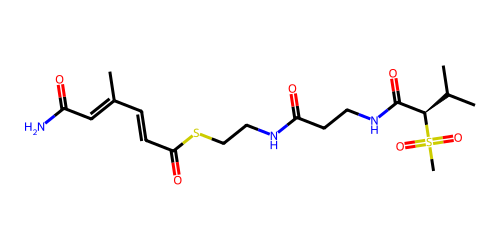

Aromatic: C1=CC=C(C=C1)C2=CC=CC=C2N(C1=O)CCC3=CC=CC=C3
Kekule:   None

Aromatic: C1=CC=C(C=C1)C2=CC=C(C=C2)N=NC3=CC=C(C=C3)N
Kekule:   NC1=CC=C(N=NC2=CC=C(C3=CC=CC=C3)C=C2)C=C1

Structure of NC1=CC=C(N=NC2=CC=C(C3=CC=CC=C3)C=C2)C=C1


[16:08:33] SMILES Parse Error: unclosed ring for input: 'C1=CC=C(C=C1)C2=CC=CC=C2N(C1=O)CCC3=CC=CC=C3'


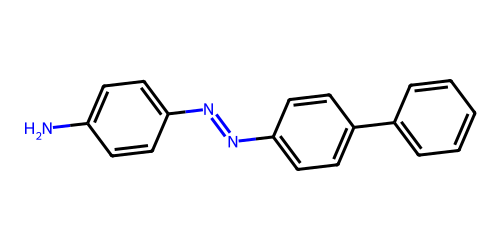

Aromatic: C1=CC=C(C=C1)C2=CC=CC=C2N=CC=O
Kekule:   O=CC=NC1=CC=CC=C1C1=CC=CC=C1

Structure of O=CC=NC1=CC=CC=C1C1=CC=CC=C1


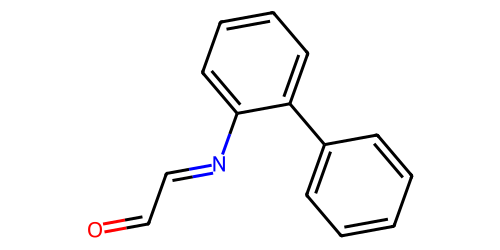

Aromatic: CC(C)(C)O
Kekule:   CC(C)(C)O

Structure of CC(C)(C)O


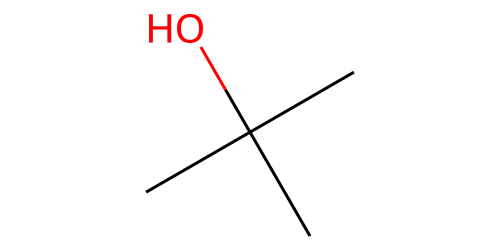

Aromatic: CSCCCCCCCCC(=O)O
Kekule:   CSCCCCCCCCC(=O)O

Structure of CSCCCCCCCCC(=O)O


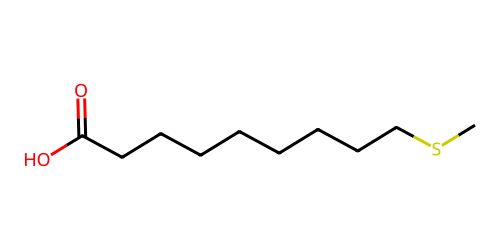

Aromatic: CSCCCCCC[C@H](C)CCCC(C)C
Kekule:   CSCCCCCC[C@H](C)CCCC(C)C

Structure of CSCCCCCC[C@H](C)CCCC(C)C


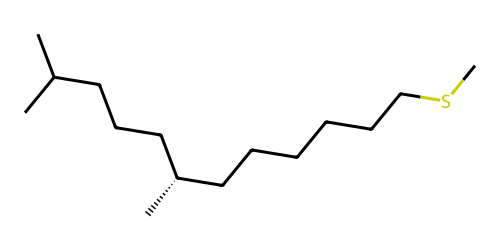

Aromatic: C1=CC=C(C=C1)C2C(C(=O)NC(=O)N2)C(=O)O
Kekule:   O=C1NC(=O)C(C(=O)O)C(C2=CC=CC=C2)N1

Structure of O=C1NC(=O)C(C(=O)O)C(C2=CC=CC=C2)N1


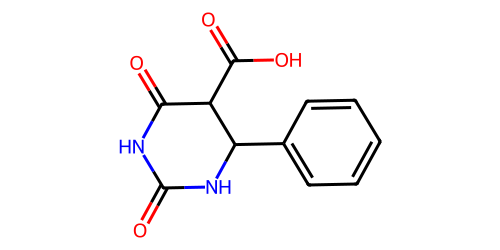

Aromatic: C1=CC=NC(=C1)S(=O)(=O)[O-]
Kekule:   O=S(=O)([O-])C1=CC=CC=N1

Structure of O=S(=O)([O-])C1=CC=CC=N1


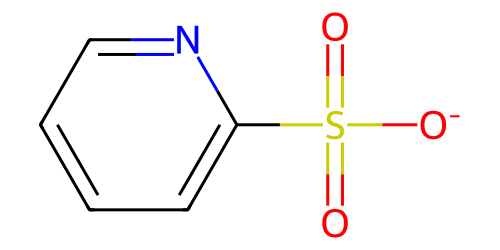

Aromatic: C1=CC(=CC=C1C(=O)N[C@@H](C2=CC=C(C=C2)S(=O)(=O)[O-])C3=CN=CC=C3
Kekule:   None

Aromatic: C1=CC=C(C=C1)/C=CC2=C(NC=N2)C3=NC=C(C=C3)C4=CN=CC=C4
Kekule:   C1=CC=C(C=CC2=C(C3=NC=C(C4=CN=CC=C4)C=C3)NC=N2)C=C1

Structure of C1=CC=C(C=CC2=C(C3=NC=C(C4=CN=CC=C4)C=C3)NC=N2)C=C1


[16:08:34] SMILES Parse Error: extra open parentheses for input: 'C1=CC(=CC=C1C(=O)N[C@@H](C2=CC=C(C=C2)S(=O)(=O)[O-])C3=CN=CC=C3'


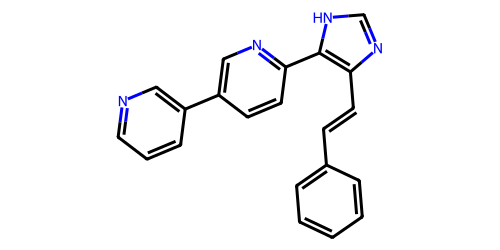

Aromatic: C1=C(C=[N+](C=C1C(=O)N)SCC(=O)[O-]
Kekule:   None

Aromatic: C1=CN(C(=O)NC1=O)[C@H]2[C@@H]([C@@H]([C@H](O2)CO)O)O
Kekule:   O=C1C=CN([C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)C(=O)N1

Structure of O=C1C=CN([C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)C(=O)N1


[16:08:34] SMILES Parse Error: extra open parentheses for input: 'C1=C(C=[N+](C=C1C(=O)N)SCC(=O)[O-]'


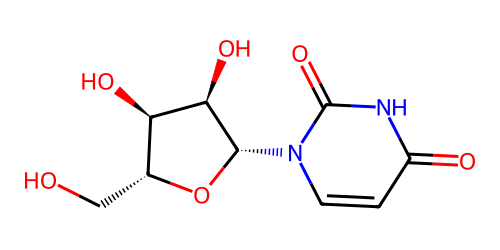

Aromatic: CC1=C(C(=C(C=C1)C)N)C
Kekule:   CC1=C(C)C(N)=C(C)C=C1

Structure of CC1=C(C)C(N)=C(C)C=C1


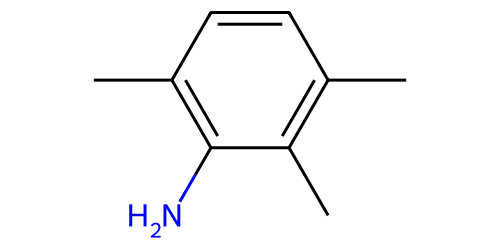

Aromatic: C(C#N)C(C(=O)O)N
Kekule:   N#CCC(N)C(=O)O

Structure of N#CCC(N)C(=O)O


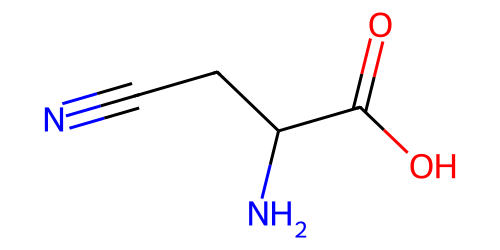

Aromatic: CC(C)(C)N
Kekule:   CC(C)(C)N

Structure of CC(C)(C)N


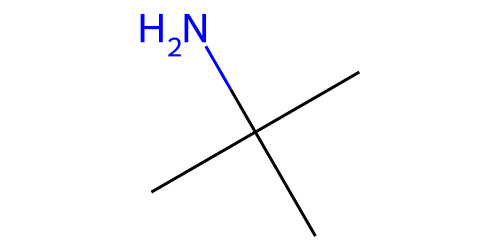

Aromatic: C1=CC=C(C=C1)C#N
Kekule:   N#CC1=CC=CC=C1

Structure of N#CC1=CC=CC=C1


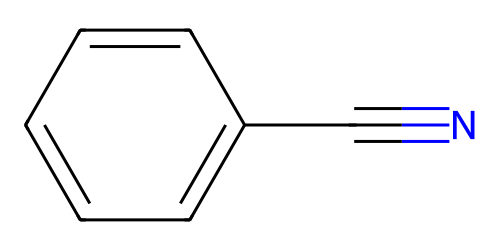

Aromatic: C1=CC=C(C=C1)C2=C(C(=C(C=C2)C#N)C#C)C#C
Kekule:   C#CC1=C(C#N)C=CC(C2=CC=CC=C2)=C1C#C

Structure of C#CC1=C(C#N)C=CC(C2=CC=CC=C2)=C1C#C


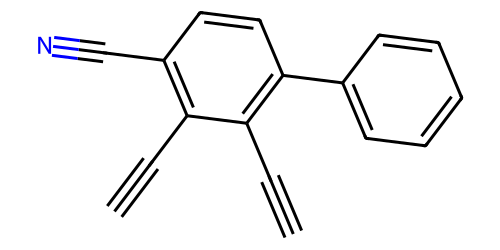

Aromatic: C1=CC=C(C=C1)C2=C(C(=CC=C2)O)C3=CC=CC=C3
Kekule:   OC1=C(C2=CC=CC=C2)C(C2=CC=CC=C2)=CC=C1

Structure of OC1=C(C2=CC=CC=C2)C(C2=CC=CC=C2)=CC=C1


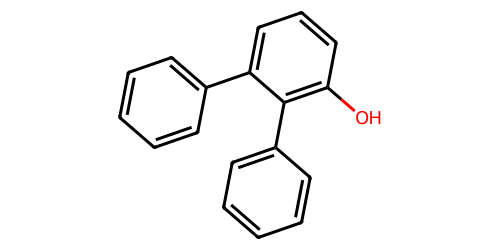

Aromatic: C1=CC=C(C=C1)NN
Kekule:   NNC1=CC=CC=C1

Structure of NNC1=CC=CC=C1


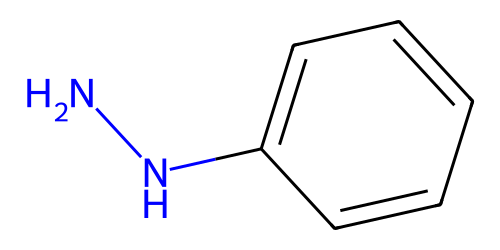

Aromatic: C1=CC=C(C=C1)C(=O)NCC(=O)[O-]
Kekule:   O=C([O-])CNC(=O)C1=CC=CC=C1

Structure of O=C([O-])CNC(=O)C1=CC=CC=C1


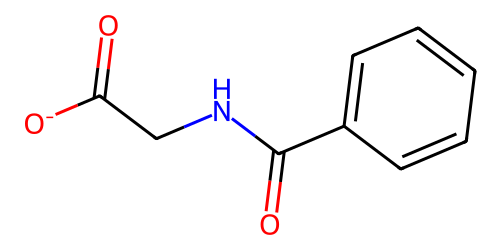

Aromatic: CC1=CC=CC=C1I
Kekule:   CC1=CC=CC=C1I

Structure of CC1=CC=CC=C1I


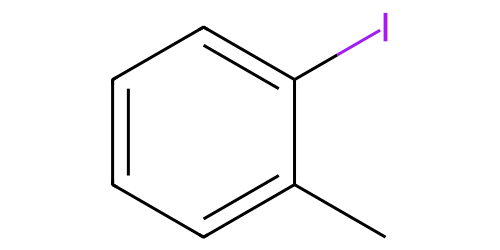

Aromatic: C1=C(C(=C(C(=C1C(=O)O)N)C(=O)O)N)C2=C(C=C(C=C2C3=CC=C(C=C3)Cl)Cl)Cl
Kekule:   NC1=C(C(=O)O)C=C(C2=C(Cl)C=C(Cl)C=C2C2=CC=C(Cl)C=C2)C(N)=C1C(=O)O

Structure of NC1=C(C(=O)O)C=C(C2=C(Cl)C=C(Cl)C=C2C2=CC=C(Cl)C=C2)C(N)=C1C(=O)O


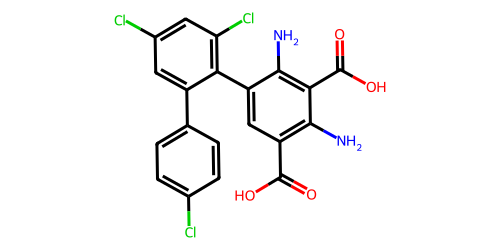

Aromatic: C1=C(C=C(C=C1C(=O)S)[C@@](C2=CC=C(C=C2)C(=O)C3=CC=CS3)C4=CC=CC=C4
Kekule:   None

Aromatic: C1=CC=C2C(=C1)C=CC(=C2N)C3=CC=CC=C3
Kekule:   NC1=C(C2=CC=CC=C2)C=CC2=CC=CC=C21

Structure of NC1=C(C2=CC=CC=C2)C=CC2=CC=CC=C21


[16:08:34] SMILES Parse Error: extra open parentheses for input: 'C1=C(C=C(C=C1C(=O)S)[C@@](C2=CC=C(C=C2)C(=O)C3=CC=CS3)C4=CC=CC=C4'


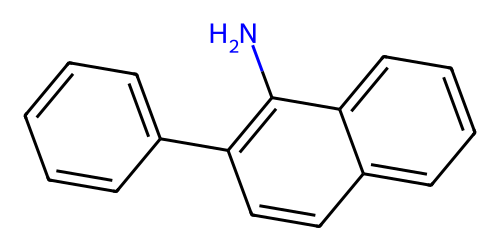

Aromatic: C1=C(C(=C(C(=C1C(=O)O)O)C(=O)[O-])C(=O)[O-])C(=O)O
Kekule:   O=C([O-])C1=C(C(=O)[O-])C(O)=C(C(=O)O)C=C1C(=O)O

Structure of O=C([O-])C1=C(C(=O)[O-])C(O)=C(C(=O)O)C=C1C(=O)O


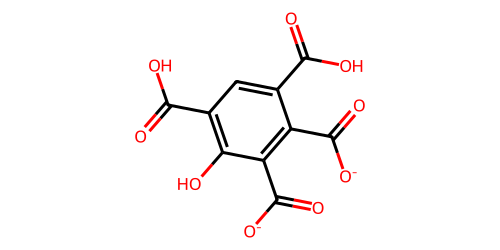

Aromatic: CC1=CSC(=C1)C(=O)O
Kekule:   CC1=CSC(C(=O)O)=C1

Structure of CC1=CSC(C(=O)O)=C1


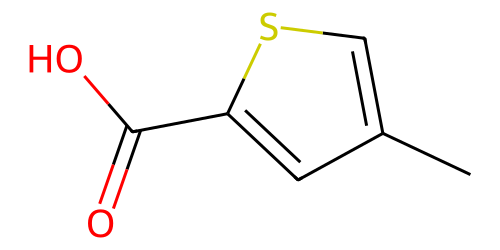

Aromatic: C1=CSC(=C1)C2=CC=C(C=C2)C(C)C
Kekule:   CC(C)C1=CC=C(C2=CC=CS2)C=C1

Structure of CC(C)C1=CC=C(C2=CC=CS2)C=C1


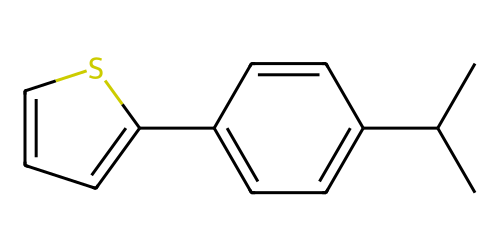

Aromatic: C1=CC=C(C(=C1)C2=CC=CC=C2N)N
Kekule:   NC1=CC=CC=C1C1=CC=CC=C1N

Structure of NC1=CC=CC=C1C1=CC=CC=C1N


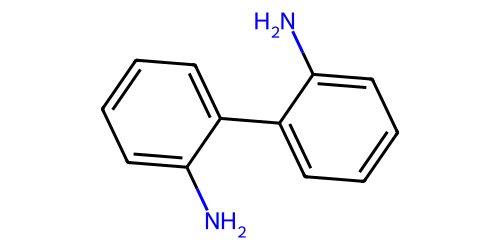

Aromatic: C1=CC=C(C=C1)C2=CC=CC=C2C3=CC=C(C=C3)N
Kekule:   NC1=CC=C(C2=CC=CC=C2C2=CC=CC=C2)C=C1

Structure of NC1=CC=C(C2=CC=CC=C2C2=CC=CC=C2)C=C1


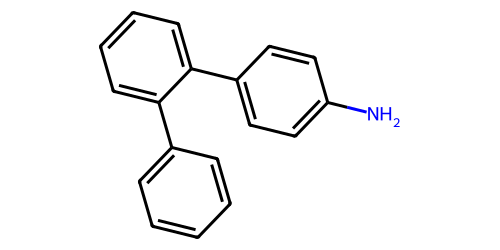

Aromatic: C1=CC(=C(C=C1C2=CC=CC=C2)C(=O)O)N
Kekule:   NC1=C(C(=O)O)C=C(C2=CC=CC=C2)C=C1

Structure of NC1=C(C(=O)O)C=C(C2=CC=CC=C2)C=C1


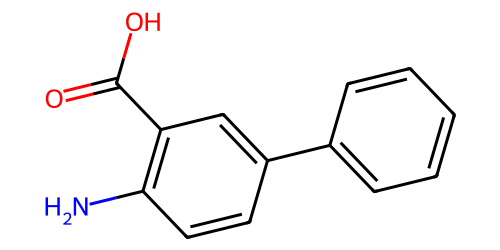

Aromatic: C1=CC=C(C=C1)C(=O)N
Kekule:   NC(=O)C1=CC=CC=C1

Structure of NC(=O)C1=CC=CC=C1


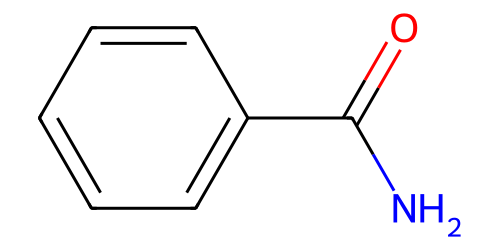

Aromatic: C/C(=CCO)/C=C/[C@H]([C@H](C)O)O
Kekule:   CC(=CCO)/C=C/[C@@H](O)[C@H](C)O

Structure of CC(=CCO)/C=C/[C@@H](O)[C@H](C)O


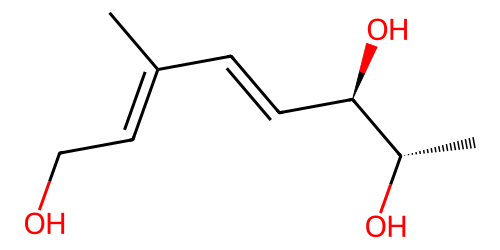

Aromatic: C1[C@H]([C@@H]([C@H]([C@@H](O1)O)O)O)O
Kekule:   O[C@@H]1[C@@H](O)[C@H](O)OC[C@H]1O

Structure of O[C@@H]1[C@@H](O)[C@H](O)OC[C@H]1O


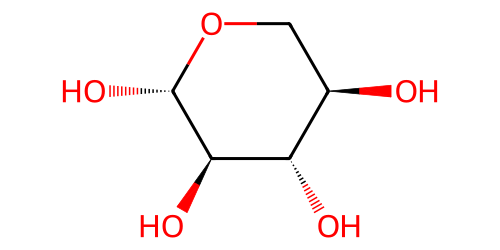

Aromatic: CC1=CC=CC=C1C(=O)[O-]
Kekule:   CC1=CC=CC=C1C(=O)[O-]

Structure of CC1=CC=CC=C1C(=O)[O-]


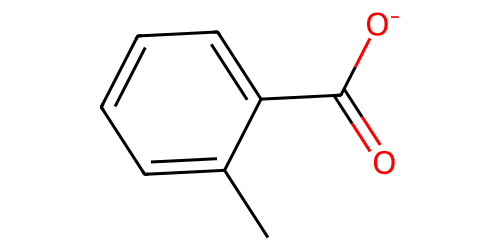

[16:08:34] SMILES Parse Error: extra close parentheses while parsing: C1=CC=C2C(=C1)C=CN=C2[C@@H]3[C@H]([C@@H]([C@H](O3)CO)O)O)O
[16:08:34] SMILES Parse Error: Failed parsing SMILES 'C1=CC=C2C(=C1)C=CN=C2[C@@H]3[C@H]([C@@H]([C@H](O3)CO)O)O)O' for input: 'C1=CC=C2C(=C1)C=CN=C2[C@@H]3[C@H]([C@@H]([C@H](O3)CO)O)O)O'
[16:08:34] SMILES Parse Error: extra close parentheses while parsing: C1[C@@H]([C@H]([C@@H](S1)CCCCC(=O)O)O)O)O
[16:08:34] SMILES Parse Error: Failed parsing SMILES 'C1[C@@H]([C@H]([C@@H](S1)CCCCC(=O)O)O)O)O' for input: 'C1[C@@H]([C@H]([C@@H](S1)CCCCC(=O)O)O)O)O'


Aromatic: C1=CC=C2C(=C1)C=CN=C2[C@@H]3[C@H]([C@@H]([C@H](O3)CO)O)O)O
Kekule:   None

Aromatic: C1[C@@H]([C@H]([C@@H](S1)CCCCC(=O)O)O)O)O
Kekule:   None

Aromatic: CSCC1=CC=CC=C1
Kekule:   CSCC1=CC=CC=C1

Structure of CSCC1=CC=CC=C1


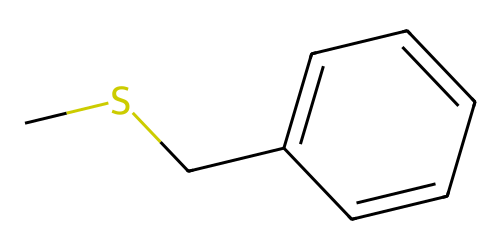

[16:08:34] SMILES Parse Error: extra close parentheses while parsing: C1=CC=C(C=C1)C2=C3C=C(C(=O)C=C3O2)N=C(C=C2C)O)O
[16:08:34] SMILES Parse Error: Failed parsing SMILES 'C1=CC=C(C=C1)C2=C3C=C(C(=O)C=C3O2)N=C(C=C2C)O)O' for input: 'C1=CC=C(C=C1)C2=C3C=C(C(=O)C=C3O2)N=C(C=C2C)O)O'
[16:08:34] SMILES Parse Error: extra open parentheses for input: 'CC(C1=CC=C(C=C1)C(=O)NCC(=O)[O-]'


Aromatic: C1=CC=C(C=C1)C2=C3C=C(C(=O)C=C3O2)N=C(C=C2C)O)O
Kekule:   None

Aromatic: CC(C1=CC=C(C=C1)C(=O)NCC(=O)[O-]
Kekule:   None

Aromatic: C1=C(C(=S)N(C1=O)C2=CC=C(C=C2)C(=O)O)C(=O)O
Kekule:   O=C(O)C1=CC=C(N2C(=O)C=C(C(=O)O)C2=S)C=C1

Structure of O=C(O)C1=CC=C(N2C(=O)C=C(C(=O)O)C2=S)C=C1


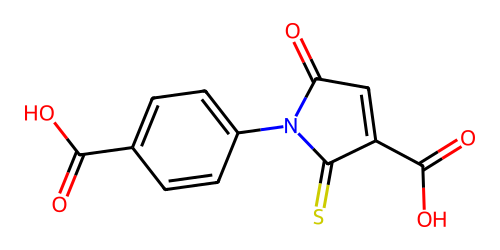

Aromatic: C1=CSC(=C1)C(=O)C2=C(N=CN=C2N)N)C(=O)O
Kekule:   None

Aromatic: C1=CSC(=C1)C(=O)CCC(=O)O
Kekule:   O=C(O)CCC(=O)C1=CC=CS1

Structure of O=C(O)CCC(=O)C1=CC=CS1


[16:08:34] SMILES Parse Error: extra close parentheses while parsing: C1=CSC(=C1)C(=O)C2=C(N=CN=C2N)N)C(=O)O
[16:08:34] SMILES Parse Error: Failed parsing SMILES 'C1=CSC(=C1)C(=O)C2=C(N=CN=C2N)N)C(=O)O' for input: 'C1=CSC(=C1)C(=O)C2=C(N=CN=C2N)N)C(=O)O'


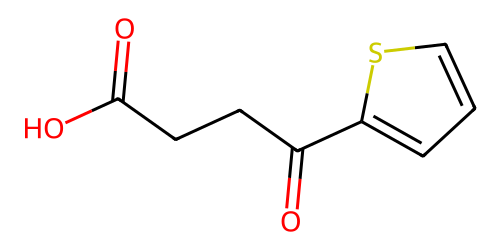

Aromatic: C1=CC=C(C=C1)C2=C(C(=CC=C2)N)O
Kekule:   NC1=CC=CC(C2=CC=CC=C2)=C1O

Structure of NC1=CC=CC(C2=CC=CC=C2)=C1O


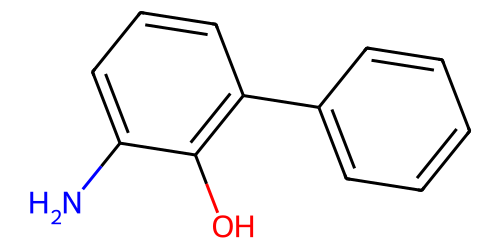

Aromatic: C1=CC=C(C=C1)C2=C(C(=CC=C2)N)C3=CC=C(C=C3)N
Kekule:   NC1=CC=C(C2=C(N)C=CC=C2C2=CC=CC=C2)C=C1

Structure of NC1=CC=C(C2=C(N)C=CC=C2C2=CC=CC=C2)C=C1


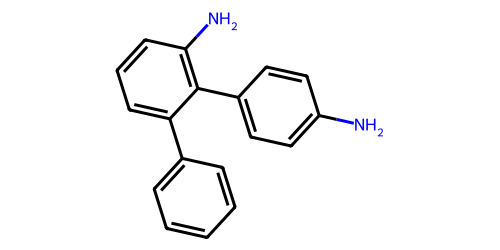

Aromatic: C1=CC=C(C=C1)C(=O)NCC2=CC=CC=C2
Kekule:   O=C(NCC1=CC=CC=C1)C1=CC=CC=C1

Structure of O=C(NCC1=CC=CC=C1)C1=CC=CC=C1


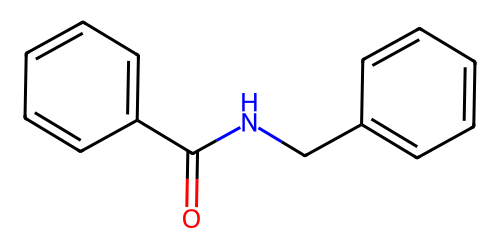

Aromatic: C1=CC=C(C=C1)C(=O)N
Kekule:   NC(=O)C1=CC=CC=C1

Structure of NC(=O)C1=CC=CC=C1


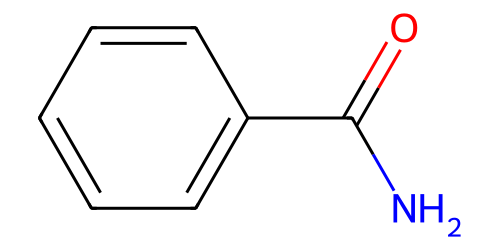

Aromatic: C1=CC=C(C=C1)C(C2=CC=CC=C2)N
Kekule:   NC(C1=CC=CC=C1)C1=CC=CC=C1

Structure of NC(C1=CC=CC=C1)C1=CC=CC=C1


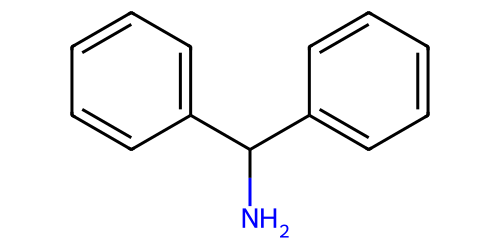

Aromatic: C1=CC=C(C=C1)C(C2=CC=CC=C2)N
Kekule:   NC(C1=CC=CC=C1)C1=CC=CC=C1

Structure of NC(C1=CC=CC=C1)C1=CC=CC=C1


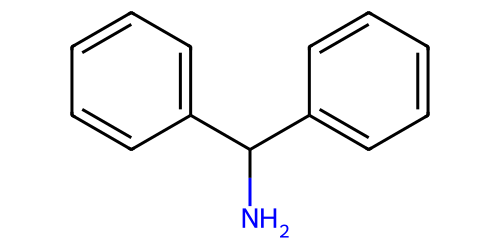

Aromatic: C1=C(C(=O)N(C1=O)C)C2=CC=NC=C2
Kekule:   CN1C(=O)C=C(C2=CC=NC=C2)C1=O

Structure of CN1C(=O)C=C(C2=CC=NC=C2)C1=O


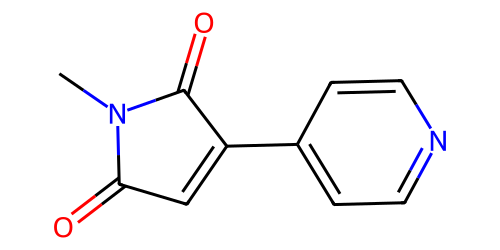

Aromatic: C1=C(C(=O)N(C=N1)N)[C@H]2[C@@H]([C@@H]([C@H](O2)CO)O)O
Kekule:   NN1C=NC=C([C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)C1=O

Structure of NN1C=NC=C([C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)C1=O


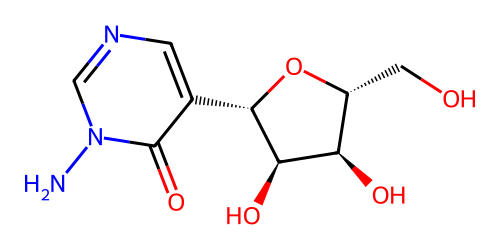

Aromatic: C1=C(C(=O)NC(=O)N1)CO
Kekule:   O=C1NC=C(CO)C(=O)N1

Structure of O=C1NC=C(CO)C(=O)N1


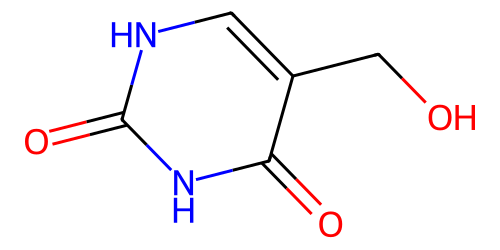

In [13]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display, Image
# 示例 SMILES（芳香式）
aromatic_smiles = mt5_generated_smiles
def de_aromatize_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    try:
        # 执行反芳香化
        Chem.Kekulize(mol, clearAromaticFlags=True)
        # 转换为显式键的 SMILES（非芳香式）
        return Chem.MolToSmiles(mol, kekuleSmiles=True)
    except Exception as e:
        print(f"Failed to kekulize {smiles}: {e}")
        return None

# 批量转换并绘制高分辨率图像
for smi in aromatic_smiles:
    # 反芳香化
    kekule = de_aromatize_smiles(smi)
    print(f"Aromatic: {smi}\nKekule:   {kekule}\n")
    
    # 显示生成结构的高分辨率图像
    if kekule:
        print(f"Structure of {kekule}")
        mol2 = Chem.MolFromSmiles(kekule)
        
        # 使用 MolDraw2DCairo 生成高分辨率图像
        drawer = Draw.MolDraw2DCairo(500, 250)  # 设置画布尺寸
        options = drawer.drawOptions()
        options.minFontSize = 10
        options.bondLineWidth = 3
        options.padding = 0.05
        # 设置 DPI
        options.dpi = 300  # 设置 DPI 为 600（高分辨率）
        
        # 绘制分子
        drawer.DrawMolecule(mol2)
        drawer.FinishDrawing()

        # 获取绘制文本并显示图像
        img_data = drawer.GetDrawingText()
        img = Image(data=img_data)
        display(img)  # 直接显示图像在 Jupyter 输出框中


Aromatic: CC(=O)C1=C(N=CC=C1)C(=O)C2=CN=CC=C2
Kekule:   CC(=O)C1=C(C(=O)C2=CN=CC=C2)N=CC=C1

Structure of CC(=O)C1=C(C(=O)C2=CN=CC=C2)N=CC=C1


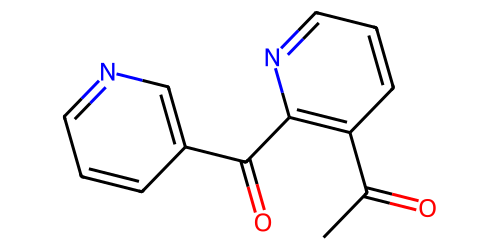

Aromatic: CC(C1=CN=C(C=C1)C(=O)C2=CC=CC=C2
Kekule:   None

Aromatic: CC(=O)CCC1=CNC2=C1C=C(C=C2)C(=O)C[C@@H](C=C2)CCC(=O)O
Kekule:   None

Aromatic: C1=CC=C(C=C1)CCC2=CC=C(C=C2)C3=CC=CC=C3
Kekule:   C1=CC=C(CCC2=CC=C(C3=CC=CC=C3)C=C2)C=C1

Structure of C1=CC=C(CCC2=CC=C(C3=CC=CC=C3)C=C2)C=C1


[16:08:37] SMILES Parse Error: extra open parentheses for input: 'CC(C1=CN=C(C=C1)C(=O)C2=CC=CC=C2'
[16:08:37] SMILES Parse Error: unclosed ring for input: 'CC(=O)CCC1=CNC2=C1C=C(C=C2)C(=O)C[C@@H](C=C2)CCC(=O)O'


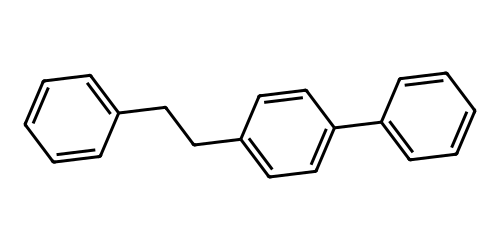

Aromatic: C1=CC=C(C=C1)CC2=CC=C(C=C2)C3=CC=CC=C3
Kekule:   C1=CC=C(CC2=CC=C(C3=CC=CC=C3)C=C2)C=C1

Structure of C1=CC=C(CC2=CC=C(C3=CC=CC=C3)C=C2)C=C1


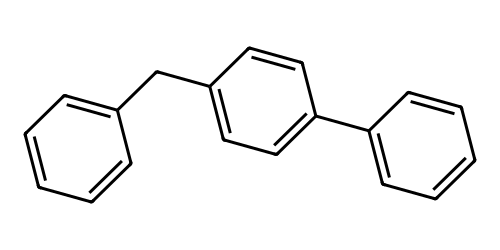

Aromatic: CCCC(=O)C(C)C1=CC=C(C=C1)C2=CC=CC=C2
Kekule:   CCCC(=O)C(C)C1=CC=C(C2=CC=CC=C2)C=C1

Structure of CCCC(=O)C(C)C1=CC=C(C2=CC=CC=C2)C=C1


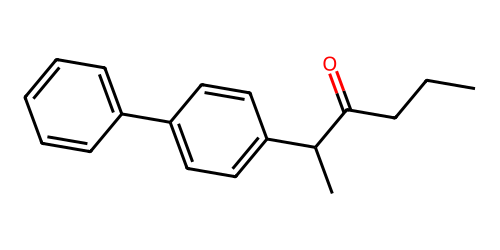

Aromatic: C12=C(C(=C(C(=C1C=C2C(=N1)C(=O)N2)C)C(=O)N[C@@H](CC3=CC=CC=C3)C4=CC=CC=C4)C=C4
Kekule:   None

Aromatic: C1=CC=C2C(=C1)C2=C(C(=C(C=C2)C)Cl)Cl
Kekule:   None

Aromatic: C1=CC=C2C(=C1)C(=O)C3=CC=CC=C3C2=O
Kekule:   O=C1C2=CC=CC=C2C(=O)C2=CC=CC=C12

Structure of O=C1C2=CC=CC=C2C(=O)C2=CC=CC=C12


[16:08:37] SMILES Parse Error: extra open parentheses for input: 'C12=C(C(=C(C(=C1C=C2C(=N1)C(=O)N2)C)C(=O)N[C@@H](CC3=CC=CC=C3)C4=CC=CC=C4)C=C4'
[16:08:37] SMILES Parse Error: unclosed ring for input: 'C1=CC=C2C(=C1)C2=C(C(=C(C=C2)C)Cl)Cl'


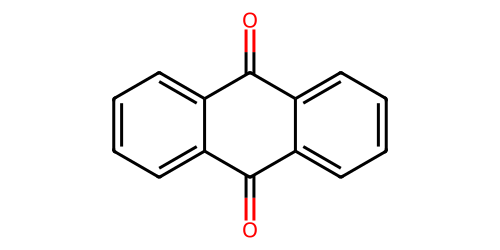

Aromatic: C1=CC(=CC=C1C[C@@H](C(=O)O)N)N
Kekule:   NC1=CC=C(C[C@H](N)C(=O)O)C=C1

Structure of NC1=CC=C(C[C@H](N)C(=O)O)C=C1


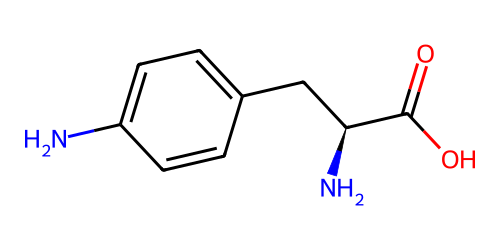

Aromatic: C1=CC=C(C(=C1)C2=CC=CC=C2
Kekule:   None

Aromatic: C1=CC(=C(C=C1C2=CC=C(C=C2)C3=CC=C(C=C3)N
Kekule:   None

Aromatic: C[C@H](C1=CC=C(C=C1)C(=O)N2C=NC=C2C(=O)[C@H](C(=O)N)C
Kekule:   None

Aromatic: C[C@@H](C1=CC=CC=C1)C2=CC(=O)C3=CC=CC=C3
Kekule:   None

Aromatic: C[C@H]([C@H](C)C(C)C(=O)O)O)C
Kekule:   None

Aromatic: C1=CC(=CN=C1)C(=O)O
Kekule:   O=C(O)C1=CN=CC=C1

Structure of O=C(O)C1=CN=CC=C1


[16:08:37] SMILES Parse Error: extra open parentheses for input: 'C1=CC=C(C(=C1)C2=CC=CC=C2'
[16:08:37] SMILES Parse Error: extra open parentheses for input: 'C1=CC(=C(C=C1C2=CC=C(C=C2)C3=CC=C(C=C3)N'
[16:08:37] SMILES Parse Error: extra open parentheses for input: 'C[C@H](C1=CC=C(C=C1)C(=O)N2C=NC=C2C(=O)[C@H](C(=O)N)C'
[16:08:37] SMILES Parse Error: unclosed ring for input: 'C[C@@H](C1=CC=CC=C1)C2=CC(=O)C3=CC=CC=C3'
[16:08:37] SMILES Parse Error: extra close parentheses while parsing: C[C@H]([C@H](C)C(C)C(=O)O)O)C
[16:08:37] SMILES Parse Error: Failed parsing SMILES 'C[C@H]([C@H](C)C(C)C(=O)O)O)C' for input: 'C[C@H]([C@H](C)C(C)C(=O)O)O)C'


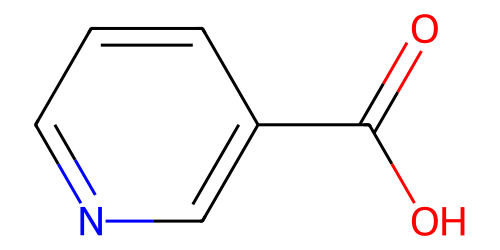

Aromatic: CC(=O)NC1=C(N=CC=C1N)C2=CC=CC=N2
Kekule:   CC(=O)NC1=C(C2=CC=CC=N2)N=CC=C1N

Structure of CC(=O)NC1=C(C2=CC=CC=N2)N=CC=C1N


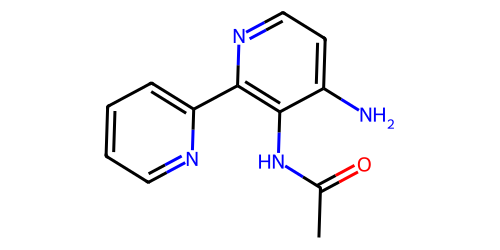

Aromatic: C1=CC=NC(=C1)C(=O)C2=C(N(C=C2)S(=O)(=O)[O-])C(=O)O
Kekule:   O=C(O)C1=C(C(=O)C2=CC=CC=N2)C=CN1S(=O)(=O)[O-]

Structure of O=C(O)C1=C(C(=O)C2=CC=CC=N2)C=CN1S(=O)(=O)[O-]


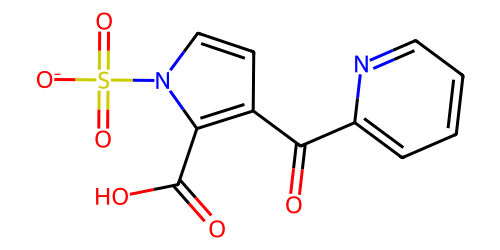

Aromatic: C1=C(N(C(=O)NC1=O)C(=O)N2C=CC(=N2)C3=CN=CC=C3
Kekule:   None

Aromatic: C1=C(C(=NC(=O)C1=O)C(=O)O)C2=CC=CC=N2
Kekule:   O=C(O)C1=NC(=O)C(=O)C=C1C1=CC=CC=N1

Structure of O=C(O)C1=NC(=O)C(=O)C=C1C1=CC=CC=N1


[16:08:38] SMILES Parse Error: extra open parentheses for input: 'C1=C(N(C(=O)NC1=O)C(=O)N2C=CC(=N2)C3=CN=CC=C3'


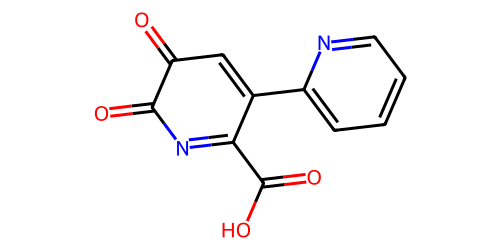

Aromatic: CC1=CN=C(N=C1)C(=O)C[C@@H](C(=O)O)N
Kekule:   CC1=CN=C(C(=O)C[C@H](N)C(=O)O)N=C1

Structure of CC1=CN=C(C(=O)C[C@H](N)C(=O)O)N=C1


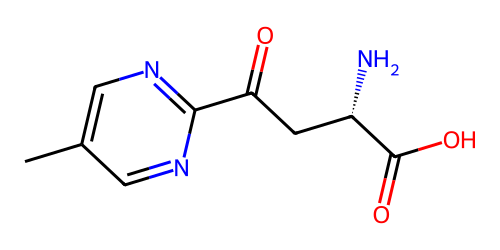

Aromatic: C[C@H](CCC1=CC=CC=C1)C2=CC=CC=C2
Kekule:   C[C@H](CCC1=CC=CC=C1)C1=CC=CC=C1

Structure of C[C@H](CCC1=CC=CC=C1)C1=CC=CC=C1


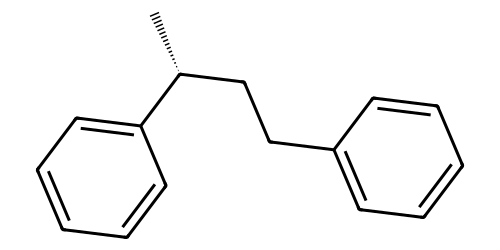

Aromatic: C1=CC=C2C(=C1)C=CC(=C2N=NC3=C(C=C(C4=CC=CC=C4)C(=O)N(C)C)C(=O)N2
Kekule:   None

Aromatic: C[C@H](C1=CC=CC=C1)C(=O)N(C)C
Kekule:   C[C@@H](C(=O)N(C)C)C1=CC=CC=C1

Structure of C[C@@H](C(=O)N(C)C)C1=CC=CC=C1


[16:08:38] SMILES Parse Error: extra open parentheses for input: 'C1=CC=C2C(=C1)C=CC(=C2N=NC3=C(C=C(C4=CC=CC=C4)C(=O)N(C)C)C(=O)N2'


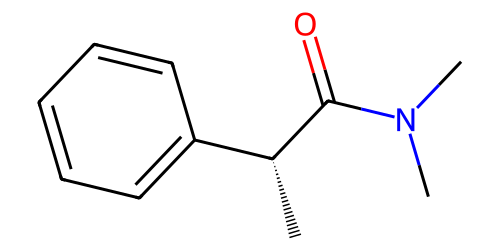

Aromatic: C1=CC=C(C=C1)N=NC2=CC=CC=C2N
Kekule:   NC1=CC=CC=C1N=NC1=CC=CC=C1

Structure of NC1=CC=CC=C1N=NC1=CC=CC=C1


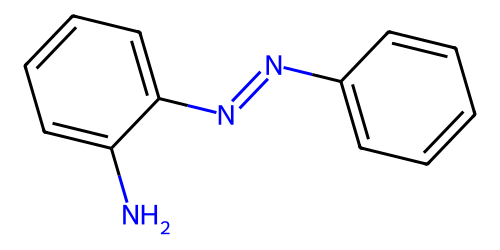

Aromatic: CC1=C(C=CC=C1C)N=C2C=CC3=CC=CC=C=C3
Kekule:   None

Aromatic: C1=CC=C(C=C1)C2=CC=CC=C2C3=CC=CC=C3
Kekule:   C1=CC=C(C2=CC=CC=C2C2=CC=CC=C2)C=C1

Structure of C1=CC=C(C2=CC=CC=C2C2=CC=CC=C2)C=C1


[16:08:38] SMILES Parse Error: unclosed ring for input: 'CC1=C(C=CC=C1C)N=C2C=CC3=CC=CC=C=C3'


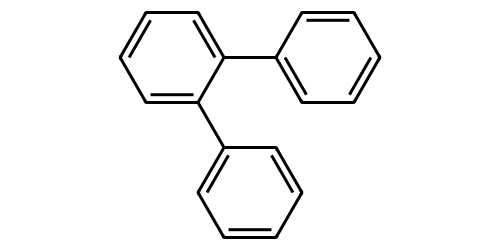

Aromatic: C1=CC=C(C(=C1)C=C(C)C)(C)C(=O)NCC2=CC=CC=C2
Kekule:   None

Aromatic: C1=CC=C2C(=C1)C=CC(=C2I
Kekule:   None

Aromatic: C1=CC=C2C(=C1)C=CC=C2O
Kekule:   OC1=CC=CC2=CC=CC=C12

Structure of OC1=CC=CC2=CC=CC=C12


[16:08:38] Explicit valence for atom # 3 C, 5, is greater than permitted
[16:08:38] SMILES Parse Error: extra open parentheses for input: 'C1=CC=C2C(=C1)C=CC(=C2I'


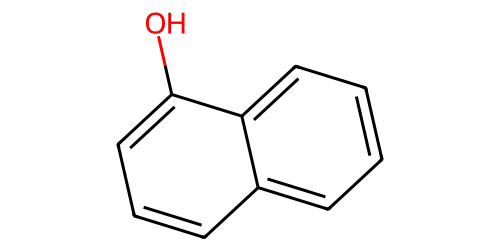

Aromatic: CSC1=CC=C(C=C1)C(=O)C2=C(C=C(C=C2)C(C)(C)C)C
Kekule:   CSC1=CC=C(C(=O)C2=C(C)C=C(C(C)(C)C)C=C2)C=C1

Structure of CSC1=CC=C(C(=O)C2=C(C)C=C(C(C)(C)C)C=C2)C=C1


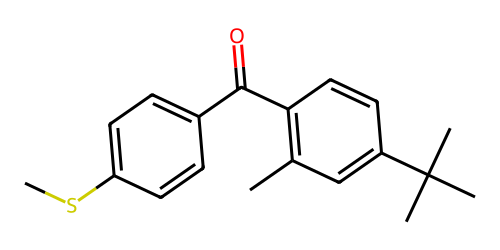

Aromatic: C1=CSC(=C1)C(=O)SCC=C(C)C2=CC=C(C=C2)S(=O)(=O)C(C)C
Kekule:   CC(=CCSC(=O)C1=CC=CS1)C1=CC=C(S(=O)(=O)C(C)C)C=C1

Structure of CC(=CCSC(=O)C1=CC=CS1)C1=CC=C(S(=O)(=O)C(C)C)C=C1


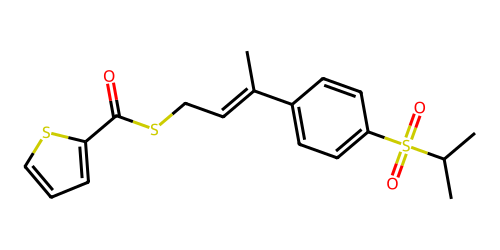

Aromatic: C1=CSC(=C1)C(=O)CC2=CC=CC=C2
Kekule:   O=C(CC1=CC=CC=C1)C1=CC=CS1

Structure of O=C(CC1=CC=CC=C1)C1=CC=CS1


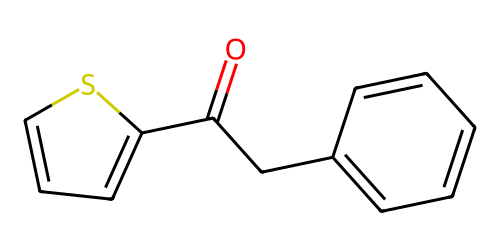

Aromatic: C1=CSC=C1C[C@H]([C@@H](CSC[C@@H](C(=O)N[C@@H]([C@@H]([C@@H](C(=O)C)C(=O)C)O)O)O
Kekule:   None

Aromatic: C1=CC=C(C=C1)C(=O)C[C@@H](C(=O)NCC(=O)NCC1=CC=C(C=C1)C(=O)NCC2=CC=CC=C2)C(=O)N
Kekule:   NC(=O)[C@@H](CC(=O)C1=CC=CC=C1)C(=O)NCC(=O)NCC1=CC=C(C(=O)NCC2=CC=CC=C2)C=C1

Structure of NC(=O)[C@@H](CC(=O)C1=CC=CC=C1)C(=O)NCC(=O)NCC1=CC=C(C(=O)NCC2=CC=CC=C2)C=C1


[16:08:38] SMILES Parse Error: extra open parentheses for input: 'C1=CSC=C1C[C@H]([C@@H](CSC[C@@H](C(=O)N[C@@H]([C@@H]([C@@H](C(=O)C)C(=O)C)O)O)O'


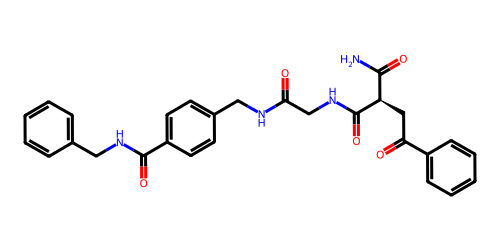

Aromatic: C1=CC=C(C=C1)C(=O)C(=O)N
Kekule:   NC(=O)C(=O)C1=CC=CC=C1

Structure of NC(=O)C(=O)C1=CC=CC=C1


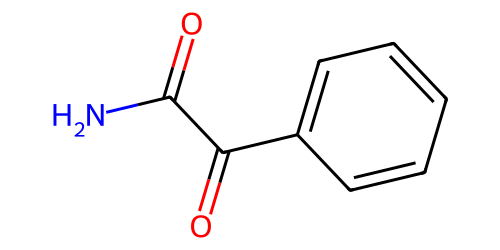

Aromatic: C1=CC=C(C(=C1)C2=CC=C(C=C2)N)N
Kekule:   NC1=CC=C(C2=CC=CC=C2N)C=C1

Structure of NC1=CC=C(C2=CC=CC=C2N)C=C1


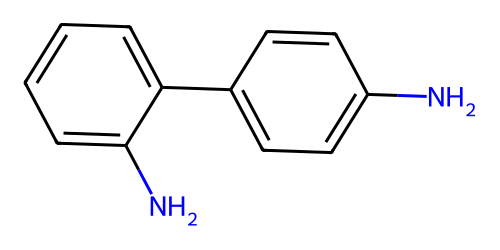

Aromatic: C1=CC(=C(C=C1C2=CC=C(C=C2)N)C3=CC=C(C=C3)N
Kekule:   None

Aromatic: C1=CC=C(C(=C1)N[C@@H](CC2=CC=CC=C2)C(=O)O
Kekule:   None

Aromatic: C1=COC=C1C(=O)CCC(=O)O
Kekule:   O=C(O)CCC(=O)C1=COC=C1

Structure of O=C(O)CCC(=O)C1=COC=C1


[16:08:38] SMILES Parse Error: extra open parentheses for input: 'C1=CC(=C(C=C1C2=CC=C(C=C2)N)C3=CC=C(C=C3)N'
[16:08:38] SMILES Parse Error: extra open parentheses for input: 'C1=CC=C(C(=C1)N[C@@H](CC2=CC=CC=C2)C(=O)O'


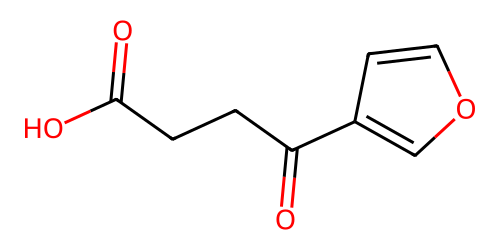

Aromatic: C1=C(C=C(C(=C1C(=O)NCCCC[C@H](C(=O)NCCCC[C@H](C(=O)N[C@@H](C(=O)N[C@H](C(=O)N[C@H](C(=O)N[C@H](C(=O)N[C@H](C(=O)N[C@H](C(=O)CC(=O)O)
Kekule:   None

Aromatic: C1=COC(=C1)C(=O)N[C@H]2C[C@@H]([C@H](O2)CO)O)O)O
Kekule:   None

Aromatic: CSCCC=CCCCCC(=O)O
Kekule:   CSCCC=CCCCCC(=O)O

Structure of CSCCC=CCCCCC(=O)O


[16:08:38] SMILES Parse Error: extra open parentheses for input: 'C1=C(C=C(C(=C1C(=O)NCCCC[C@H](C(=O)NCCCC[C@H](C(=O)N[C@@H](C(=O)N[C@H](C(=O)N[C@H](C(=O)N[C@H](C(=O)N[C@H](C(=O)N[C@H](C(=O)CC(=O)O)'
[16:08:38] SMILES Parse Error: extra close parentheses while parsing: C1=COC(=C1)C(=O)N[C@H]2C[C@@H]([C@H](O2)CO)O)O)O
[16:08:38] SMILES Parse Error: Failed parsing SMILES 'C1=COC(=C1)C(=O)N[C@H]2C[C@@H]([C@H](O2)CO)O)O)O' for input: 'C1=COC(=C1)C(=O)N[C@H]2C[C@@H]([C@H](O2)CO)O)O)O'


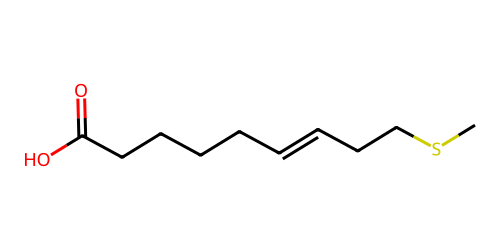

Aromatic: C[C@@H]([C@H]1C(=CC2=C(C=C2S(=O)(=O)O)S(=O)(=O)O)N
Kekule:   None

Aromatic: C(C(C(=O)O)N)C(=O)N
Kekule:   NC(=O)CC(N)C(=O)O

Structure of NC(=O)CC(N)C(=O)O


[16:08:38] SMILES Parse Error: extra open parentheses for input: 'C[C@@H]([C@H]1C(=CC2=C(C=C2S(=O)(=O)O)S(=O)(=O)O)N'


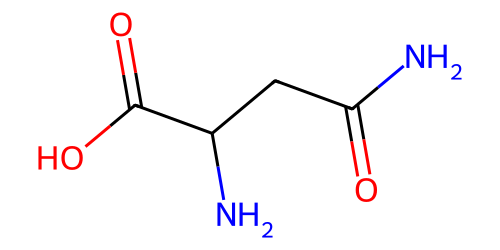

Aromatic: C1=CC=C2C(=C1)C(=CC(=C2C)C3=CC=C(C=C3)S(=O)(=O)O)C4=CC=C(C=C4)S(=O)(=O)O
Kekule:   CC1=C(C2=CC=C(S(=O)(=O)O)C=C2)C=C(C2=CC=C(S(=O)(=O)O)C=C2)C2=CC=CC=C21

Structure of CC1=C(C2=CC=C(S(=O)(=O)O)C=C2)C=C(C2=CC=C(S(=O)(=O)O)C=C2)C2=CC=CC=C21


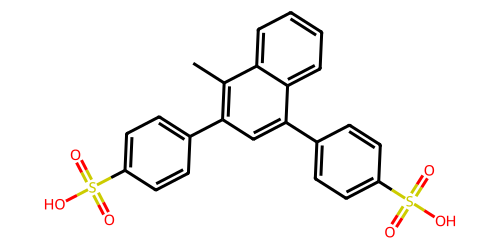

Aromatic: CC(C)C1=CC2=C(C=C1)N=C(C=C2)C=C(C3=CC=CC=C3C2=O)S(=O)(=O)O
Kekule:   None

Aromatic: C[C@H]1[C@@H]([C@@H]([C@H]([C@H](O1)O)O)O)O)O
Kekule:   None

Aromatic: C1=CC=C(C=C1)C(=O)NCC2=CC=CC=C2
Kekule:   O=C(NCC1=CC=CC=C1)C1=CC=CC=C1

Structure of O=C(NCC1=CC=CC=C1)C1=CC=CC=C1


[16:08:38] SMILES Parse Error: unclosed ring for input: 'CC(C)C1=CC2=C(C=C1)N=C(C=C2)C=C(C3=CC=CC=C3C2=O)S(=O)(=O)O'
[16:08:38] SMILES Parse Error: extra close parentheses while parsing: C[C@H]1[C@@H]([C@@H]([C@H]([C@H](O1)O)O)O)O)O
[16:08:38] SMILES Parse Error: Failed parsing SMILES 'C[C@H]1[C@@H]([C@@H]([C@H]([C@H](O1)O)O)O)O)O' for input: 'C[C@H]1[C@@H]([C@@H]([C@H]([C@H](O1)O)O)O)O)O'


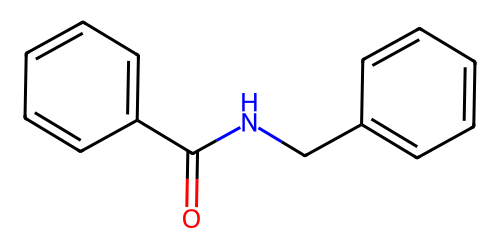

Aromatic: C1=CSC(=C1)C(=O)CCCCCCCCC(=O)O
Kekule:   O=C(O)CCCCCCCCC(=O)C1=CC=CS1

Structure of O=C(O)CCCCCCCCC(=O)C1=CC=CS1


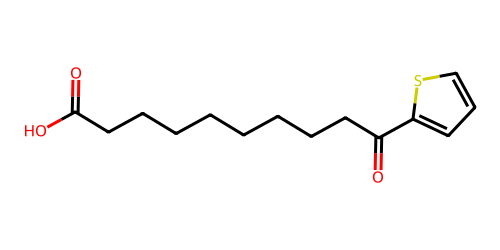

Aromatic: CSC1=CC=C(C=C1)C2=NC3=CC=CC=C3
Kekule:   None

Aromatic: C1=CC=C2C(=C1)C=CC3=CC=CC=C3C4=CC=CC=C4
Kekule:   None

Aromatic: C1=CC=C(C=C1)C(=O)C2=CC=CC=C2
Kekule:   O=C(C1=CC=CC=C1)C1=CC=CC=C1

Structure of O=C(C1=CC=CC=C1)C1=CC=CC=C1


[16:08:38] SMILES Parse Error: unclosed ring for input: 'CSC1=CC=C(C=C1)C2=NC3=CC=CC=C3'
[16:08:38] SMILES Parse Error: unclosed ring for input: 'C1=CC=C2C(=C1)C=CC3=CC=CC=C3C4=CC=CC=C4'


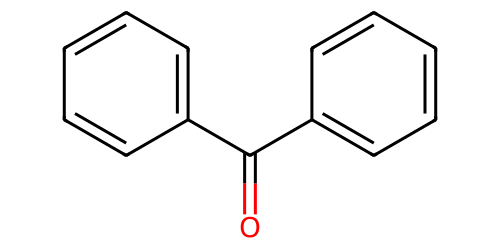

Aromatic: C1=CC=C2C(=C1)C=CC3=CC=CC=C32
Kekule:   C1=CC=C2C(=C1)C=CC1=CC=CC=C12

Structure of C1=CC=C2C(=C1)C=CC1=CC=CC=C12


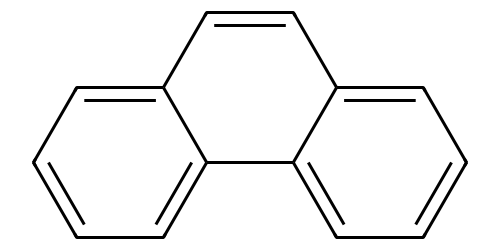

Aromatic: C1=CC=C(C=C1)C2=CC=CC=C2
Kekule:   C1=CC=C(C2=CC=CC=C2)C=C1

Structure of C1=CC=C(C2=CC=CC=C2)C=C1


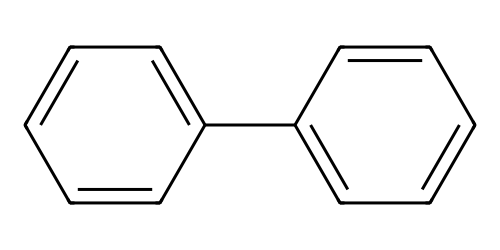

Aromatic: C1=CC=C2C(=C1)C=CC(=C2N)N
Kekule:   NC1=C(N)C2=CC=CC=C2C=C1

Structure of NC1=C(N)C2=CC=CC=C2C=C1


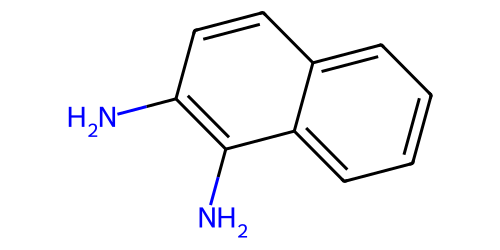

Aromatic: C1=CC=C2C(=C1)C=CC=C2
Kekule:   C1=CC=C2C=CC=CC2=C1

Structure of C1=CC=C2C=CC=CC2=C1


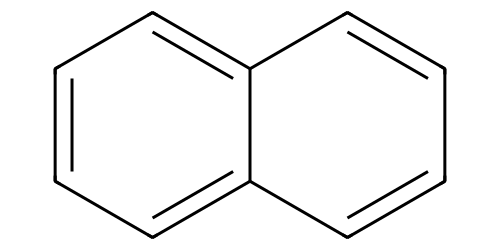

Aromatic: CCCC1=C(N=C(C(=N1)N)N)C2=C(NC=C2)C3=CN=CC=C3
Kekule:   CCCC1=C(C2=C(C3=CN=CC=C3)NC=C2)N=C(N)C(N)=N1

Structure of CCCC1=C(C2=C(C3=CN=CC=C3)NC=C2)N=C(N)C(N)=N1


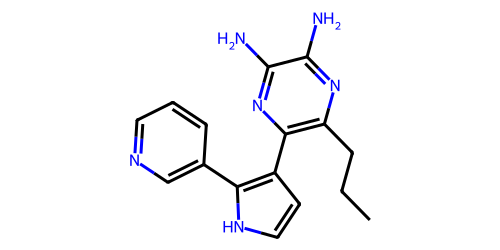

Aromatic: C1=C(C(=O)NC(=O)N1
Kekule:   None

Aromatic: C1=C(C(=O)NC(=O)N1
Kekule:   None



[16:08:38] SMILES Parse Error: extra open parentheses for input: 'C1=C(C(=O)NC(=O)N1'
[16:08:38] SMILES Parse Error: extra open parentheses for input: 'C1=C(C(=O)NC(=O)N1'


In [14]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display, Image
# 示例 SMILES（芳香式）
aromatic_smiles = t5_generated_smiles
def de_aromatize_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    try:
        # 执行反芳香化
        Chem.Kekulize(mol, clearAromaticFlags=True)
        # 转换为显式键的 SMILES（非芳香式）
        return Chem.MolToSmiles(mol, kekuleSmiles=True)
    except Exception as e:
        print(f"Failed to kekulize {smiles}: {e}")
        return None

# 批量转换并绘制高分辨率图像
for smi in aromatic_smiles:
    # 反芳香化
    kekule = de_aromatize_smiles(smi)
    print(f"Aromatic: {smi}\nKekule:   {kekule}\n")
    
    # 显示生成结构的高分辨率图像
    if kekule:
        print(f"Structure of {kekule}")
        mol2 = Chem.MolFromSmiles(kekule)
        
        # 使用 MolDraw2DCairo 生成高分辨率图像
        drawer = Draw.MolDraw2DCairo(500, 250)  # 设置画布尺寸
        options = drawer.drawOptions()
        options.minFontSize = 10
        options.bondLineWidth = 3
        options.padding = 0.05
        # 设置 DPI
        options.dpi = 300  # 设置 DPI 为 600（高分辨率）
        
        # 绘制分子
        drawer.DrawMolecule(mol2)
        drawer.FinishDrawing()

        # 获取绘制文本并显示图像
        img_data = drawer.GetDrawingText()
        img = Image(data=img_data)
        display(img)  # 直接显示图像在 Jupyter 输出框中
